# TU060 - Data Mining

#### Student: Eamonn Kelly
#### student #: D24127620

#### Assignment - Text Mining


## Content Outline
### Step 1 . Data Understanding and Preparation (20 points)

- 1.1 Problem Definition:
    - 1.2 Data Preparation
    - 1.2a Import data set and analyse structure
    - 1.2b - Initial Data – Pre-Cleaning
    - 1.2c - Cleaning tasks - Issues to Address
    - 1.2d - Standardise 'review_time#' to an anchored date of today to provide a **relative** timeframe for the review data
    - 1.2e - Create a new numeric only 'star_rating' column
    - 1.2f - Split the 'store_address' column into its component parts
    - 1.2g - Create unique 'store_id' column
    - 1.2h - Fix corrupt characters in 'store_name' column
    - 1.2i - Remove the 'review' row containing single character '?' review
    - 1.2j - Final verification of dataset and creation of final working df

## Step 2. Data Visualization and Exploration (20 points)

- 2.1 - Data Exploration & Descriptive Analytics
    - 2.1a - Plot of number of stores per state
    - 2.1b - Plot the performance ratings per store using mean, median and cumulative methodologies applied to star ratings
    - 2.1c - Tabular comparison of top 5 and worst 5 stores across mean, median and cumulative
    - 2.1d - Plot of mean performance rating per store
    - 2.1e - Plot of number of reviews per store
    - 2.1f - Plot of Ratings over derived time
    - 2.1g - Plot of Lickert Scale for ratings data
    - 2.1h - Create word frequency count and word cloud
    - 2.1i - Create positive and negative word lists and plot from 'star_rating _num' data
- 2.2 - Visualise Review Embeddings using UMAP
## Step 3. Model Building and Evaluation (20 points)

- 3.1 Details of Algorithms & Configurations
    - 3.1a - Prepare and validate the Dataset
    - 3.1b - Perform log ratio comparison to identify words associated with positive and negative reviews and plot results
    - 3.1c - Prepare for and run supervised learning with a binary sentiment scenario and a TF–IDF vectorised Logistic Regression model
    - 3.1d - Perform 'Naive Bayes', 'Linear SVM' and 'SGD Logistic' modelling on our binary sentiment data
    - 3.1e - PLot ROC Curves all together - Logistic Regression, 'Naive Bayes', 'Linear SVM', 'SGD Logistic'
    - 3.1f - Generate confusion matrix for all 4 models
    - 3.1g - Generate 'Precision', 'Recall' and 'F1' matrix for all 4 models
    - 3.1h - Best Model Choice Analysis
## 4. Advanced Techniques and Analysis (20 points)
- 4.1 - Clustering of Review Embedding using K-Means

### Improvement / Future Work
### References

## Step 1 . Data Understanding and Preparation (20 points)

### 1.1 Problem Definition:

Identify sentiment feedback that we can integrate into the McDonalds business decision making process to ac upon, which can have a direct business impact. 

<u>Question</u>: Can we identify Negative sentiment feedback which can be used to improve services and offerings, and also Identify Positive sentiment feedback to improve services and offerings and ultimately improve the business.


In [1]:
import pandas as pd
import numpy as np
import csv
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from urllib.request import urlopen
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict
from pathlib import Path
from ydata_profiling import ProfileReport
import math

import matplotlib.pyplot as plt

import io 
import re
import os
import json
import seaborn as sns
from io import StringIO
from pprint import pprint
from datetime import datetime, timedelta

from nltk.stem import WordNetLemmatizer

from sklearn.datasets import load_files
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score


nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eamon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eamon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\eamon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 1.2 Data Preparation

1.2a Import data set and analyse structure

In [2]:
#defining global variable path to files and data, it is called thropughout modify this path to match your local path
path = './'


Import csv

McDoalds review dataset was downloaded from Kaggle - https://www.kaggle.com/datasets/nelgiriyewithana/mcdonalds-store-reviews


In [3]:
# csv was downlaoded from url above an the imported using read_csv here
mcd_df = pd.read_csv(os.path.join(path, 'McDonald_s_Reviews.csv'), encoding="ISO-8859-1")

mcd_df.head(20)

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star
5,6,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 weeks ago,I work for door dash and they locked us all ou...,1 star
6,7,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,If I could give this location a zero on custo...,1 star
7,8,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a year ago,Came in and ordered a Large coffee w/no ice. T...,1 star
8,9,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Went thru drive thru. Ordered. Getting home no...,1 star
9,10,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,"I'm not really a huge fan of fast food, but I ...",4 stars


Get the dtypes per column

In [4]:
print(mcd_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB
None


Get stats on numerical data in the data set

In [5]:
print(mcd_df.describe())

        reviewer_id     latitude      longitude
count  33396.000000  32736.000000  32736.000000
mean   16698.500000     34.442546    -90.647033
std     9640.739131      5.344116     16.594844
min        1.000000     25.790295   -121.995421
25%     8349.750000     28.655350    -97.792874
50%    16698.500000     33.931261    -81.471414
75%    25047.250000     40.727401    -75.399919
max    33396.000000     44.981410    -73.459820


Assess general cleanliness of data, missing values, duplicates, rogue characters etc

In [6]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_df.shape[0])
print ("Columns  : " , mcd_df.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_df.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_df.nunique())
print('------')
print('\n null values = ', mcd_df.isnull().values.any())
print('------')
mcd_df_missing = (mcd_df=='?').sum()
print('\"  ?   \" values present =  \n',mcd_df_missing)
print('------')
mcd_df_unknown = (mcd_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_df_unknown)
print('------')
mcd_df_na = mcd_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_df_na)
print('------')
mcd_df_none = mcd_df.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_df_none)
print('------')
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
rogue_ascii_df = mcd_df.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", rogue_ascii_df)

Rows     :  33396
Columns  :  10
------

Features : 
 ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating']
------

Missing values :   1320
------

Missing values per column:   reviewer_id        0
store_name         0
category           0
store_address      0
latitude         660
longitude        660
rating_count       0
review_time        0
review             0
rating             0
dtype: int64
------

num of dups in df   =   0
------

Unique values :  
 reviewer_id      33396
store_name           2
category             1
store_address       40
latitude            39
longitude           39
rating_count        51
review_time         39
review           22285
rating               5
dtype: int64
------

 null values =  True
------
"  ?   " values present =  
 reviewer_id      0
store_name       0
category         0
store_address    0
latitude         0
longitude        0
rating_count     0
review_time     

Check the non ascii characters int he flagged columns from earlier

In [7]:
# get list of columns contianing no ascii characters - convert ti to a list to sue later
ascii_cols = rogue_ascii_df[rogue_ascii_df > 0].index.tolist()


for col_name in ascii_cols:
    print(f" =========== {col_name} ==================")
    # create a boolean mask series , ensure dtype is str, if str contains anythgi outsid eof ascii range if missing values allocate as not macthing
    mask = mcd_df[col_name].astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False )
    
    # view the numebr of rows affected and then the actual non ascii row, only once tho
    print(f" number of rows with non ascii  =  {mask.sum()}")
    print(mcd_df.loc[mask, col_name].drop_duplicates().head(20))





 =========== store_name ==================
 number of rows with non ascii  =  71
500    ýýýMcDonald's
Name: store_name, dtype: object
 =========== store_address ==================
 number of rows with non ascii  =  660
22141    2476 Kalï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
Name: store_address, dtype: object
 =========== review ==================
 number of rows with non ascii  =  3037
2     Made a mobile order got to the speaker and che...
3     My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...
7     Came in and ordered a Large coffee w/no ice. T...
9     I'm not really a huge fan of fast food, but I ...
10    Worst McDonaldï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
18    I am not happy at all today I went and bought ...
24    Didnï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½...
25    McDonaldï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
27    Doesnï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...
29    First and last time I go to this location. Loo...
34    We hit it off pretty good in the beginning

Inspect review data containing '?' character

In [8]:
# check occurence f '?' character in the dataframe
# crteate a boolean mask for cells which contain  '?' character , do on row level, ie. axis = 1
mask = mcd_df.eq("?").any(axis=1)

# display onyl the row where this occurs i.e apply the mask t the dataframe
mcd_df.loc[mask]


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
19669,19670,McDonald's,Fast food restaurant,"621 Broadway, Newark, NJ 07104, United States",40.77191,-74.161475,"1,564",6 years ago,?,2 stars


Check the unique values where there are low numbers of them to check to have a quick look

In [9]:
# view the unique values where there are lwo numbers of them to check to have a quick look
print("=================   store_name   =======================")
print(f" store_name values - count = {(mcd_df["store_name"].nunique())}")
print(f" store_name values = {(mcd_df["store_name"].unique())}")


print("=================   category  =======================")
print(f" category values - count = {(mcd_df['category'].nunique())}")
print(f" category values = {(mcd_df['category'].unique())}")


print("=================   rating  =======================")
print(f" rating values - count = {(mcd_df['rating'].nunique())}")
print(f" rating values = {(mcd_df['rating'].unique())}")


print("=================   review_time  =======================")
print(f" rating values - count = {(mcd_df['review_time'].nunique())}")
print(f" rating values = {(mcd_df['review_time'].unique())}")


print("=================   rating_count  =======================")
print(f" rating values = {(mcd_df['rating_count'].nunique())}")
print(f" rating values = {(mcd_df['rating_count'].unique())}")



=================   store_name   =======================
 store_name values - count = 2
 store_name values = ["McDonald's" "ýýýMcDonald's"]
=================   category  =======================
 category values - count = 1
 category values = ['Fast food restaurant']
=================   rating  =======================
 rating values - count = 5
 rating values = ['1 star' '4 stars' '5 stars' '2 stars' '3 stars']
=================   review_time  =======================
 rating values - count = 39
 rating values = ['3 months ago' '5 days ago' 'a month ago' '2 months ago' '3 weeks ago'
 'a year ago' '6 months ago' '5 months ago' '7 months ago' '10 months ago'
 '4 years ago' '8 months ago' '4 months ago' '3 years ago' '2 years ago'
 '9 months ago' '11 months ago' '5 years ago' '6 years ago' '7 years ago'
 '8 years ago' '3 days ago' 'a week ago' '2 days ago' '2 weeks ago'
 '10 years ago' '9 years ago' '6 days ago' '4 weeks ago' '21 hours ago'
 '4 days ago' '11 years ago' '12 years ago' 'a day

Get the number of unique 'rating_counts' per store

In [10]:
# this is a snaphsot of a count of reviews at a time when a  review was posted.
# won't get a lot of te proal data ouf it as max count for a store is two and min is one.... 
# may be useful to see which stores get reviewed the most and which don't  
print(mcd_df.groupby("store_address")["rating_count"].nunique())



store_address
1044 US-11, Champlain, NY 12919, United States                                2
10451 Santa Monica Blvd, Los Angeles, CA 90025, United States                 1
10901 Riverside Dr, North Hollywood, CA 91602, United States                  2
1100 N US Hwy 377, Roanoke, TX 76262, United States                           2
111 Madison St, Oak Park, IL 60302, United States                             1
1121 Garnet Ave, San Diego, CA 92109, United States                           1
11382 US-441, Orlando, FL 32837, United States                                1
114 Delancey St, New York, NY 10002, United States                            1
13749 US-183 Hwy, Austin, TX 78750, United States                             1
1415 E State Rd, Fern Park, FL 32730, United States                           2
151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States     1
1540 2nd St, Santa Monica, CA 90405, United States                            2
160 Broadway, New York, NY

Check to see of what class python object types are  i.e. str

In [11]:
# check to see actual python objhect types 
for col in mcd_df.select_dtypes(include="object").columns:
    print(col, mcd_df[col].map(type).value_counts())


store_name store_name
<class 'str'>    33396
Name: count, dtype: int64
category category
<class 'str'>    33396
Name: count, dtype: int64
store_address store_address
<class 'str'>    33396
Name: count, dtype: int64
rating_count rating_count
<class 'str'>    33396
Name: count, dtype: int64
review_time review_time
<class 'str'>    33396
Name: count, dtype: int64
review review
<class 'str'>    33396
Name: count, dtype: int64
rating rating
<class 'str'>    33396
Name: count, dtype: int64


Check to see if python 'object' columns contain alpha, numeric of mixture of both



In [12]:
# loop through the columns where type is object, we'll exclude int / float
for col in mcd_df.select_dtypes(include="object").columns:
    # loop through each column
    # check if row string contains digits using regex
    # digits anywhere in the text and if its nan label as no digits, True is one digit in a row int he column
    digits_present = mcd_df[col].str.contains(r"\d", na=False).any()
    print(f" {col} ---- contain digits and Text  - True/False = {digits_present}")


 store_name ---- contain digits and Text  - True/False = False


 category ---- contain digits and Text  - True/False = False
 store_address ---- contain digits and Text  - True/False = True
 rating_count ---- contain digits and Text  - True/False = True
 review_time ---- contain digits and Text  - True/False = True
 review ---- contain digits and Text  - True/False = True
 rating ---- contain digits and Text  - True/False = True


1.2b - Initial Data – Pre-Cleaning

- Data shape = (33,396, 10) > 33, 396 rows of data and 10 columns, parameter variables
    - Column analysis
        - 'reviewer_id'
            - dtype  = int  - numeric, unique ID, primary key
            - discrete data 
        - store_name
            - dtype = python object - str class - text, no variation in data.
            - categorical data
            - 71 rows with non ascii character present, same type for each row  =  ["McDonald's" "ýýýMcDonald's"]
            - we will fix this.
            - column data won't hold much value in later analysis work as contains no variation.
        - 'store_address'
            - dtype = python object - str class - alpha numeric, need to split out
            - categorical data
            - 1 non-ascii characters present - 
            - 660 rows with non ascii character,  same type for each row  = '2476 Kalï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...''
            - will not modify as will address with 'store_id' solution
        - 'category'
            - dtype = python object - str class - text, no variation in data.
            - categorical data
            - of the type of restaurant
            - only 1 type,  ["Fast food restaurant"]
            - again, column won't hold much value in later analysis work as contains no variation.
        - 'latitude' -  
            - dtype  = float  - numeric (decimal, pos and neg) 
            - continous data
            - may be useful later for spatial analysis if possible
        - 'longtitude'
            - dtype  = float  - numeric (decimal, pos and neg)
            - continuos data
            - may be useful later for spatial analysis if possible
        - 'ratings_count'
            - dtype = python object - str class - numeric
            - discrete data 
            - number of reviews per store at the time the particular review we have in our data was posted, 
            - have a lot of repeated values as the number remained the same when review was posted.
            - there are 51 unique values but there are only 40 stores.
            - Not sure how reliable a metric this is ...
        - 'review' 
            - dtype = python object - text based content, str type.
            - unstructured data
            - contains actual review text for the store
            - All appears to be english langauge
            - Non-ascii chracters present, many differnt types
            - 3037 rows containing some form of non-ascii character. 
            - Some appear to be apostrophes i.e.  'Didnï¿½ï¿½ï¿ïï¿½...'',  'McDonaldï¿½ï¿½ï¿½½ï¿...'',  'Doesnï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï' and thus retain meaning
                - as such we will not modify or tr fix. wil leave as is and preserve meaning as is.
            - onw row contains '?' character as placeholder value. This adds no data/meaning to dataset. ASs such will remove this row as is just noise.
        - 'rating' 
            - dtype - python object - alphanumeric content
            - categorical  - ordinal data
            - contains numerical star rating for the store
            - will strip out rating number to separate standalone column , 'star_rating_num' so can use more easily.
- Missing Values
    - Present in Longitude and Latitude columns only
    - 660 in each
- No Duplicate entries
- No ‘null,’, ‘unknown’, 'na’, ‘none’, present in the data.
- 40 different store addresses
- Reviewers
    - 33,396 unique users 
    - 22,285 unique rows of feedback.
    - Either some reviewers left no feedback or we have identical/near identical feedback.
    - Requires further analysis
- Numerical Data
    - Is spatial data and unique user IDs.
    - of limited use for analysis directly at this stage
- Encoding
    - tried different coding types during import of csv data i.e. 'utf-8', 'latin1', 'cp1252'
    - none addressed corrupt characters issue identified earlier i.e. many character types 'ï¿½' among others
    - Ended up using 'ISO-8859-1' so could import without error and not lose amy more data
    - This is most likely due to incorrect encoding used during initial scraping, storage or transfer of data to csv. Unable to recover original characters.
    - Will leave as is to preserve review text meaning as is.

	

1.2c - Cleaning tasks - Issues to Address
    
- 'review_time'
    - mixture of alpha numeric data and mixture of relative timelines ie.. '23 Hours ago', '1 day ago', '6 months aga', '10 years ago'
    - We have data from < 1 day ago to 10 years + ago. These do not have the same validity and as such need to categorise to be able to easily identify and distinguish data relevance.
- 'rating'
    - mixture of alphanumeric data i.e. '1 star', '2 star', etc
    - create numeric only rating so can more easily manipulate, count, aggregate etc 
- 'store_address'
    - Split out Address into its component parts, all us more easily manipulate, aggregate and display, i.e. categorise per state, etc
- 'store_address'
    - Create unique 'store_id'
    - plots of stores are very busy as the store_address is long mixed string, 
    - create a unique ID for each store which will be easier to d display during plotting
    - reviewer Id will remain primary key in the data, as it is unique per row,
- 'store_name'
    - fix single cell corruption
- 'review'
    - remove row containing just the '?' character as a review. It is placeholder review, contains no data, only noise in our dataset.
        




1.2d - Standardise 'review_time' to an anchored date of today to provide a **relative** timeframe for the review data

We have data from < 1 day ago to 10 years + ago. These do not have the same validity and as such need to categorise to be able to easily identify and distinguish data relevance.

We will use todays date as an anchor date to extrapolate backwards and provide a relative timeframe for when the review was received, thus allowing us determine a relative ordering  for reviews i.e. when were they received relative to each other. It is not intended to identify real calendar dates for submission, as we do not know this and cannot determine from the data.

Standardised the column time. It is a **relative** time that is provided, so cannot infer a date/time. We will categorise as follows

we have 39 unique values for review_time, will create a list of these and put them into categories.

- 1 week ago =  than 7 days
- 1 month ago = between 8 days and 30 days
- 

view 'review_time' unique values

Create Function to map the *review_time* column text to a relative time frame

In [13]:
# we will define a time 'today from 'today' from which we will determine a relative time
today = pd.Timestamp.today().normalize()

In [14]:
# create a fucntion we can apply to the text
# functino is needed as theres a bit of variation in the data structure, is cleanest emthod
def review_time_to_cat(text):
    # convet to lower casee to standardise and remove and leading /trailing whitespace
    text = text.lower().strip()
    
    # break it down into repeateable time elements in the data    
    if "hour" in text:
        # extract the digit and f none, defautl to 1.
        # https://pandas.pydata.org/docs/user_guide/timedeltas.html
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        # use timedelta > subtract n hours from todays date t get a datetime value
        # https://pandas.pydata.org/docs/user_guide/timedeltas.html
        # timdelat expects nanoseconds, so must explicitly specify a unti 'hours' to subract from todays date
        return today - pd.Timedelta(hours=n)
    
    if "day" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        return today - pd.Timedelta(days=n)
    
    if "week" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        return today - pd.Timedelta(weeks=n)
    
    if "month" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        # months are no standared timeframe, vary in duration so need to account for that wth dateoffset
        # dateoffset is calendar aware pd fiunction, adjusts per month from todays date
        # https://pandas.pydata.org/docs/reference/api/pandas.tseries.offsets.DateOffset.html
        return today - pd.DateOffset(months=n)
    
    if "year" in text:
        n = int(re.findall(r"\d+", text)[0]) if re.findall(r"\d+", text) else 1
        # years are non standard also, as above have leap years, as such use dateofset function
        return today - pd.DateOffset(years=n)
    
    # if none of the above conditions are met return not a time value as a plceholder missing time value
    return pd.NaT

Apply the function on the *review_time* column

In [15]:
# create a copy of the dataframe  - keep original in case need to roll back or refer to
mcd_time_df = mcd_df.copy()

# create ne w column to store new data
mcd_time_df['review_relative_time'] = mcd_df['review_time'].apply(review_time_to_cat)

Verify the changes

In [16]:
print(mcd_time_df['review_relative_time'].isna().sum())
mcd_time_df.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33396 non-null  int64         
 1   store_name            33396 non-null  object        
 2   category              33396 non-null  object        
 3   store_address         33396 non-null  object        
 4   latitude              32736 non-null  float64       
 5   longitude             32736 non-null  float64       
 6   rating_count          33396 non-null  object        
 7   review_time           33396 non-null  object        
 8   review                33396 non-null  object        
 9   rating                33396 non-null  object        
 10  review_relative_time  33396 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 2.8+ MB


1.2e - Create a new numeric only 'star_rating' column

Contains text like '1 star', '2 star' etc

View and verify current unique values

In [17]:
sorted(mcd_time_df['rating'].unique())

['1 star', '2 stars', '3 stars', '4 stars', '5 stars']

Create function to translate mixture of alphanumeric daa to just numeric.


In [18]:
# input a text valeu into the function
def rating_to_num(text):
    # if nan value int he text just return none
    if pd.isna(text):
        return None
    # convetr to lowercase and strip leading and trailing white space
    # make sure we're gettig a str aswell
    # assign it the variable name text
    text=str(text).lower().strip()
    
    # esearch for first occurrent of a digit between 1 to 5 and assign to rating_num variable
    # http://regex101.com
    rating_num=re.search(r'[1-5]', text)
    
    # convert the character to an int
    # rating_num is not a int or a strong its an regex object contianing the date , so have ot explicitly convert it
    # .group will get the exact num from the original text that matched the regex, need group as ratimg_
    # https://docs.python.org/3/howto/regex.html
    if rating_num:
        return int(rating_num.group())
    # if none of those conditions are met reyurn none
    return None
    
    

Apply the function tp the ratign column

In [19]:
# craete a copyh of the dataframe so don't mes sup original and ca roolback and call original as we need
mcd_time_rating_df = mcd_time_df.copy()
#capply fucntion to data columna nd cterate new column to store the output
mcd_time_rating_df["star_rating_num"] = mcd_time_rating_df["rating"].apply(rating_to_num)

Verify the change

In [20]:
mcd_time_rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33396 non-null  int64         
 1   store_name            33396 non-null  object        
 2   category              33396 non-null  object        
 3   store_address         33396 non-null  object        
 4   latitude              32736 non-null  float64       
 5   longitude             32736 non-null  float64       
 6   rating_count          33396 non-null  object        
 7   review_time           33396 non-null  object        
 8   review                33396 non-null  object        
 9   rating                33396 non-null  object        
 10  review_relative_time  33396 non-null  datetime64[ns]
 11  star_rating_num       33396 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 3.1+ M

Sorted reviews by date time (newest first) and also by star rating (highest first) to view the most recent and most positive feedback, to verify successful implementation of derived columns

In [21]:
mcd_time_rating_df_sorted = mcd_time_rating_df.sort_values(by=["review_relative_time", "star_rating_num"], ascending=[False, False])
                                                           
mcd_time_rating_df_sorted.head(10)


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating,review_relative_time,star_rating_num
16042,16043,McDonald's,Fast food restaurant,"8500 US-290, Austin, TX 78724, United States",30.329135,-97.660629,"1,406",6 hours ago,I came here for a Uber eats order and their sy...,1 star,2025-12-20 18:00:00,1
29363,29364,McDonald's,Fast food restaurant,"1415 E State Rd, Fern Park, FL 32730, United S...",28.655350,-81.342692,"1,618",8 hours ago,Worst customer service ever,1 star,2025-12-20 16:00:00,1
19772,19773,McDonald's,Fast food restaurant,"621 Broadway, Newark, NJ 07104, United States",40.771910,-74.161475,"1,564",20 hours ago,They always mess up orders or give you the wro...,1 star,2025-12-20 04:00:00,1
2784,2785,McDonald's,Fast food restaurant,"72-69 Kissena Blvd, Queens, NY 11367, United S...",40.727401,-73.812460,"2,193",21 hours ago,My kids favorite,5 stars,2025-12-20 03:00:00,5
16041,16042,McDonald's,Fast food restaurant,"8500 US-290, Austin, TX 78724, United States",30.329135,-97.660629,"1,406",21 hours ago,Fresh food,5 stars,2025-12-20 03:00:00,5
25278,25279,McDonald's,Fast food restaurant,"7010 Bradlick Shopping Center, Annandale, VA 2...",38.812823,-77.185055,595,22 hours ago,Terrible,1 star,2025-12-20 02:00:00,1
11817,11818,McDonald's,Fast food restaurant,"1121 Garnet Ave, San Diego, CA 92109, United S...",32.797661,-117.249470,"1,159",23 hours ago,This McDonald's does 1 order per hour after mi...,1 star,2025-12-20 01:00:00,1
5651,5652,McDonald's,Fast food restaurant,"5920 Balboa Ave, San Diego, CA 92111, United S...",32.820654,-117.178011,550,a day ago,Excellent,5 stars,2025-12-20 00:00:00,5
13871,13872,McDonald's,Fast food restaurant,"6875 Sand Lake Rd, Orlando, FL 32819, United S...",28.450387,-81.471414,"19,671",a day ago,This place is crazy packed. Our food came out ...,5 stars,2025-12-20 00:00:00,5
16989,16990,McDonald's,Fast food restaurant,"10901 Riverside Dr, North Hollywood, CA 91602,...",34.152507,-118.367904,"1,795",a day ago,"Super fast, what I liked is that they have sev...",5 stars,2025-12-20 00:00:00,5


1.2f - Split the 'store_address' column into its component parts

will leave the object dtypes as str as numbers are not int values 

Create a function to split out the address into its component parts 

In [22]:
# had to do several iterations of this and amend as issues arose and items were mal sorted
# some mis formed address, rogue commans, unexpected prefixes vlvd way, 

# def into which we will feed and address - text/str onbject
def split_address_fn(address):
    # if address isn't nan return a panda series object wth 6 elements 
    # these will be street_num, street_name, city, state, zip_code, country
    if pd.isna(address):
        # need set number of columns., .apply crashes is missing any when functino is run
        return pd.Series([None, None, None, None, None, None])
    
    # split the address by commas and srtip any leading  / training white spaces 
    # so ahve sepaate parts to work with based on commas
    parts = [p.strip() for p in address.split(",")]
    
    # -=== street number and street name =====
    number = None
    street = None
    if len(parts) > 0:
        # assign street number and name to par5 0 i.e. the first element
        street_part = parts[0]
        # use regex to match parts match > 1 digit, include hyphens (as some rpresent), inclue space and anythgin else up to comma
        # run it against the full street part of the object
        # https://docs.python.org/3/library/re.html
        # two groups define din regex demarcted by parenthesis I(first is digitis - second is street name, anythign else)
        match = re.match(r"^(\d+[\-\d]*)\s+(.*)$", street_part)
        # if was a regex match aabove and is nto nan
        # if no nujmber we keep the full string for earlier street_part definition first part of object
        if match:
            # match if it has a number
            # asigne regex group 1 to numebr
            number = match.group(1)
            # assign regex group 2 to street
            street = match.group(2)
        else:
            # if no numebr default to original definition
            street = street_part
    
    # === city === 
    # assigning second part of comma separated field if theres more than one part
    # otherwaise leave as none
    city = parts[1] if len(parts) > 1 else None
    
    # === zip code and state ====-
    # assigning state to third part of the split object
    state = None
    zip_code = None
    if len(parts) > 2:
        # assign the third part of the objct to state and zip and zip to the second part of that
        state_zip = parts[2]
        # split that string into two parts with state being th efirst [0] and zip being the second [1]
        tokens = state_zip.split()
        if len(tokens) >= 1:
            state = tokens[0]
        if len(tokens) >= 2:
            zip_code = tokens[1]
    
    # ==== Country -===
    # 
    country = parts[3] if len(parts) > 3 else None
    
    # ==== had to add specific fixes for individual  mis sorting, form theb las vagega mandalay bay store which has a prefix...====
    # not an ideal dolution as nto geneal enough btu sufficient for our purposes given the time constraints
    # if city name contains 
    if city and "Las Vegas Blvd" in city:
        city = "Las Vegas"

    # if state contaisn Las nstead of nevada, change to below 
    if state == "Las":
        state = "NV"

    # onyl one store in vegas by mandalay bay - https://www.mcdonalds.com/us/en-us/location/nv/las-vegas/3999-s-las-vegas-blvd-by-mandalay-bay/22506.html
    # used that zip code....
    # if word vegas is present in zip code - replace with with 89119 value as per above
    if zip_code == "Vegas":
        zip_code = "89119"

    # if the state zip code value is present in country code, replace it with US value
    if country == "NV 89119":
        country = "United States"

    # fi country value is missing  - default to US
    if country is None:
        country = "United States"
    
    return pd.Series([number, street, city, state, zip_code, country])


Apply the Function

In [23]:
# # craete a copyh of the dataframe so don't mes sup original and ca roolback and call original as we need
mcd_time_rating_addr_df= mcd_time_rating_df.copy()

#capply fucntion to data columna nd cterate new column to store the output
# we'll use .apply to call it
mcd_time_rating_addr_df[["street_number", "street_name", "city", "state", "zip_code", "country"]] = mcd_time_rating_addr_df["store_address"].apply(split_address_fn)


Verify the changes and extraction was as expected

In [24]:
print(mcd_time_rating_addr_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33396 non-null  int64         
 1   store_name            33396 non-null  object        
 2   category              33396 non-null  object        
 3   store_address         33396 non-null  object        
 4   latitude              32736 non-null  float64       
 5   longitude             32736 non-null  float64       
 6   rating_count          33396 non-null  object        
 7   review_time           33396 non-null  object        
 8   review                33396 non-null  object        
 9   rating                33396 non-null  object        
 10  review_relative_time  33396 non-null  datetime64[ns]
 11  star_rating_num       33396 non-null  int64         
 12  street_number         32366 non-null  object        
 13  street_name     

In [25]:
# ctate list tok check the contents
addr_cols = ["street_number", "street_name", "city", "state", "zip_code", "country"]

# loop through the colmns and list the unique values, see if they are as expected
for col in addr_cols:
    print(f" ========= {col} ===========")
    print(mcd_time_rating_addr_df[col].dropna().unique())


 ========= street_number ===========
['13749' '1698' '72-69' '429' '724' '160' '555' '10451' '114' '5920' '262'
 '490' '550' '11382' '210' '1916' '151' '690' '1650' '1121' '1044' '501'
 '1540' '6875' '25200' '111' '8500' '10901' '702-2' '1100' '621' '2400'
 '2476' '5725' '1415' '9814' '7010' '632' '3501']
 ========= street_name ===========
['US-183 Hwy' 'US-209' 'Kissena Blvd' '7th Ave' 'Broadway' '13th St NW'
 'Santa Monica Blvd' 'Delancey St' 'Balboa Ave' 'Canal St' '8th Ave'
 'Lawrence Expy' 'US-441' '5th S' 'M St NW'
 "West 34th Street (Macy's 7th Floor" 'Alameda St' 'Washington Ave'
 'Garnet Ave' 'US-11' 'W Imperial Hwy' '2nd St' 'Sand Lake Rd'
 'I-10 Lot 2' 'Madison St' 'US-290' 'Riverside Dr' 'Haddonfield-Berlin Rd'
 'N US Hwy 377' 'Alliance Gateway Fwy' 'By Mandalay Bay'
 'Kalï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½'
 'W Irlo Bronson Memorial Hwy' 'E State Rd' 'International Dr'
 'Bradlick Shopping Center' 'S R L Thornton Freeway Service Rd'
 'Biscayne Blvd']
 ========= ci

1.2g - Create unique 'store_id' column

In [26]:
# creat a work ing copy of the df
mcd_time_rating_addr_sid_df= mcd_time_rating_addr_df.copy()

# create new column define it a dtype categorical data, so its not numeric or str text
# extract the category codes assigned for each address and if the same allcoate the same id
# https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.codes.html
# https://stackoverflow.com/questions/51102205/how-to-know-the-labels-assigned-by-astypecategory-cat-codes
# Looked at label encoding here but seems like overkill, cat.codes seemed simpler
mcd_time_rating_addr_sid_df["store_id"] = (mcd_time_rating_addr_sid_df["store_address"].astype("category").cat.codes)


Verify was created successfully

In [27]:
# print the count of unique values and also the unique values themselves, just print to have a quick look
print(mcd_time_rating_addr_sid_df["store_id"].nunique())
print(mcd_time_rating_addr_sid_df["store_id"].unique())

# disolkayh one to one mapping fo the store id to the address, theres no dups and we cna see the mapping 
print(mcd_time_rating_addr_sid_df[["store_id", "store_address"]].drop_duplicates().sort_values("store_id").head(10))


40
[ 8 14 35 22 36 12 26  1  7 28 20 23 25  6 16 15 10 32 13  5  0 24 11 31
 19  4 37  2 34  3 29 17 39 18 27  9 38 33 30 21]
       store_id                                      store_address
11890         0     1044 US-11, Champlain, NY 12919, United States
5254          1  10451 Santa Monica Blvd, Los Angeles, CA 90025...
16270         2  10901 Riverside Dr, North Hollywood, CA 91602,...
18163         3  1100 N US Hwy 377, Roanoke, TX 76262, United S...
14660         4  111 Madison St, Oak Park, IL 60302, United States
11210         5  1121 Garnet Ave, San Diego, CA 92109, United S...
7750          6     11382 US-441, Orlando, FL 32837, United States
5257          7  114 Delancey St, New York, NY 10002, United St...
0             8  13749 US-183 Hwy, Austin, TX 78750, United States
23561         9  1415 E State Rd, Fern Park, FL 32730, United S...


1.2h - Fix corrupt characters in 'store_name' column

In [28]:
# creat a work ing copy of the df
mcd_time_rating_addr_sid_nm_df= mcd_time_rating_addr_sid_df.copy()

# only one issue identified ehre, so just doing simple replace, not generalising in function or general corrupt character 
mcd_time_rating_addr_sid_nm_df["store_name"] = (mcd_time_rating_addr_sid_nm_df["store_name"].replace("ýýýMcDonald's", "McDonald's"))


verify fix

In [29]:
# print the count of unique values and also the unique values themselves, just print to have a quick look
print(mcd_time_rating_addr_sid_nm_df["store_name"].nunique())
print(mcd_time_rating_addr_sid_nm_df["store_name"].unique())

1
["McDonald's"]


1.2i - Remove the 'review' row containing single character '?' review

In [30]:
# crate copy to work in
mcd_time_rating_addr_sid_nm_rev_df= mcd_time_rating_addr_sid_nm_df.copy()

# remove the row
# mcd_time_rating_addr_sid_nm_rev_df.loc[mcd_df["review"] == "?", "review"] = None


# mask = mcd_df.eq("?").any(axis=1)

# # display onyl the row where this occurs i.e apply the mask t the dataframe
# mcd_df.loc[mask]

mcd_time_rating_addr_sid_nm_rev_df = (mcd_time_rating_addr_sid_nm_rev_df[mcd_time_rating_addr_sid_nm_rev_df["review"] != "?"])



Verify safe removal of the row

In [31]:
(mcd_time_rating_addr_sid_nm_rev_df["review"] == "?").sum()


0

1.2j - Final verification of dataset and creation of final working df

More detailed verification was performed after each issue was addressed above, btu for clealiness of the notebook, am not showing all verification checks that were performed.

In [32]:
# createb final workign copy 
mcd_df_1 = mcd_time_rating_addr_sid_nm_rev_df.copy()

In [33]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_df_1.shape[0])
print ("Columns  : " , mcd_df_1.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_df_1.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_df_1.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_df_1.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_df_1.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_df_1.nunique())
print('------')
print('\n null values = ', mcd_df_1.isnull().values.any())
print('------')
mcd_df_1_missing = (mcd_df_1 =='?').sum()
print('\"  ?   \" values present =  \n',mcd_df_1_missing)
print('------')
mcd_df_1_unknown = (mcd_df_1 =='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_df_1_unknown)
print('------')
mcd_df_1_na = mcd_df_1.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_df_1_na)
print('------')
mcd_df_1_none = mcd_df_1.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_df_1_none)
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
print('------')
mcd_df_1_rogue_ascii_df = mcd_df_1.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", mcd_df_1_rogue_ascii_df)

Rows     :  33395
Columns  :  19
------

Features : 
 ['reviewer_id', 'store_name', 'category', 'store_address', 'latitude ', 'longitude', 'rating_count', 'review_time', 'review', 'rating', 'review_relative_time', 'star_rating_num', 'street_number', 'street_name', 'city', 'state', 'zip_code', 'country', 'store_id']
------

Missing values :   4330
------

Missing values per column:   reviewer_id                0
store_name                 0
category                   0
store_address              0
latitude                 660
longitude                660
rating_count               0
review_time                0
review                     0
rating                     0
review_relative_time       0
star_rating_num            0
street_number           1030
street_name                0
city                     660
state                    660
zip_code                 660
country                    0
store_id                   0
dtype: int64
------

num of dups in df   =   0
------

Unique v

In [34]:
mcd_df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33395 entries, 0 to 33395
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewer_id           33395 non-null  int64         
 1   store_name            33395 non-null  object        
 2   category              33395 non-null  object        
 3   store_address         33395 non-null  object        
 4   latitude              32735 non-null  float64       
 5   longitude             32735 non-null  float64       
 6   rating_count          33395 non-null  object        
 7   review_time           33395 non-null  object        
 8   review                33395 non-null  object        
 9   rating                33395 non-null  object        
 10  review_relative_time  33395 non-null  datetime64[ns]
 11  star_rating_num       33395 non-null  int64         
 12  street_number         32365 non-null  object        
 13  street_name          

Final verification completed and dataframe looks as we expect at this stage.

- Dataframe name = 'mcd_df_1'
- shape -  started with 33396 rows and 10 columns  - ended up with  > (33395, 19)
    - removed one invalid review row, '?' row has been removed successfully
- Missing value 
    - total = 4330
    - is consistent with the data we obtained originally in the csv and tied into store details, lat, long, ciy, state, zip_codes ans treet number with 1030. 
    - No random missing values
- Duplicates
    - None



## Step 2. Data Visualization and Exploration (20 points)

First we will look at the best performign stores i.e. the stores with the highest numb er of 5 star ratings

we cna do this because of our derived 

### 2.1 - Data Exploration & Descriptive Analytics


2.1a - Plot of number of stores per state

we calculate this by gettign value counts per state column and sorting

In [35]:
# keep one row per store
stores_df = ( mcd_df_1[["store_id", "state"]].drop_duplicates())

# count stores per state
stores_per_state = stores_df["state"].value_counts().sort_values(ascending=False)

stores_per_state


state
NY    9
CA    8
FL    7
TX    6
DC    2
NJ    2
PA    1
UT    1
IL    1
NV    1
VA    1
Name: count, dtype: int64

Create a function to save plot as png file for use in report later

In [36]:

def save_file(fig_name):
    datetime_stamp = datetime.now().strftime('%d%m%y_%H')
    file_path_name = f'{path}{fig_name}_{datetime_stamp}.png'
    plt.savefig(file_path_name, dpi=300, bbox_inches="tight")
    plt.show()
    print(f' Saved file {file_path_name}')

plot the number of stores per state

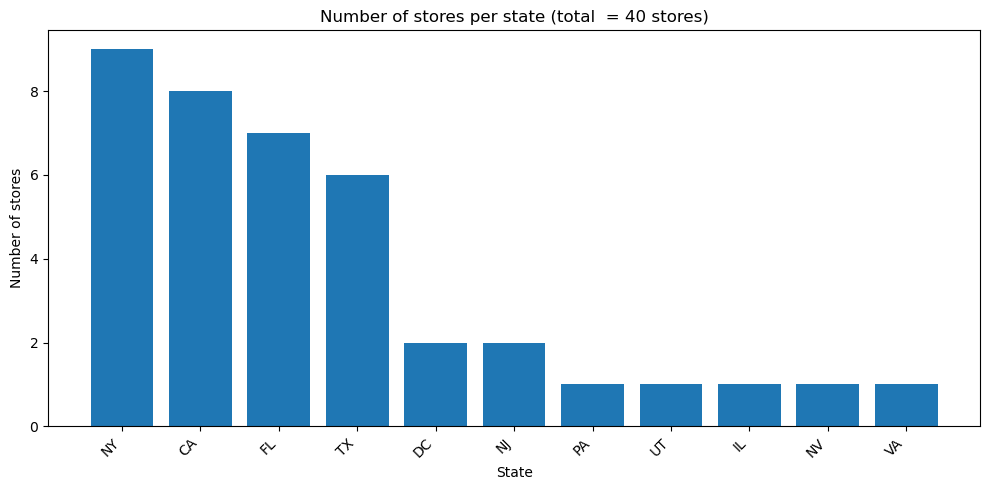

 Saved file ./number_of_stores_per_state_211225_23.png


In [37]:
# craete plor of calculated data
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(stores_per_state.index, stores_per_state.values)

ax.set_xlabel("State")
ax.set_ylabel("Number of stores")
ax.set_title("Number of stores per state (total  = 40 stores)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# call our save_file function
save_file('number_of_stores_per_state')
plt.show()


2.1b - Plot the performance ratings per store using mean, median and cumulative methodologies applied to star ratings

we calcualate three different methods on star ratig and see how they compare in determining performance.

we calculate this by multiplying rating adding up all the ratings so it is weighte by rating count i.e. higher ratig gcount will give it a higher value

In [38]:
# create a df t store the performance metrics and aggregate on mean, median and sum (cumulatitive) values 
# group by the store_id and select star_rating_num
# these will be groped creatign one row per store and oen column per plotting metric
store_perf_df = (mcd_df_1.groupby("store_id")["star_rating_num"].agg(mean_rating="mean", median_rating="median", cumulative_rating="sum",      review_count="size"))


In [39]:
# sort the store_perf_df by mean_rating value 
store_perf_sorted = store_perf_df.sort_values(by="mean_rating", ascending=False)

# need to craete positional values for the plot, othersie df rows are sorted but bars drawn at original numeric positions by maplotlib
x = np.arange(len(store_perf_sorted))



Plot all three performance metrics. We wil plot all three based on ascending order of 'mean' this will allow an easier comparison across all three, rather than re-calculating for each one.

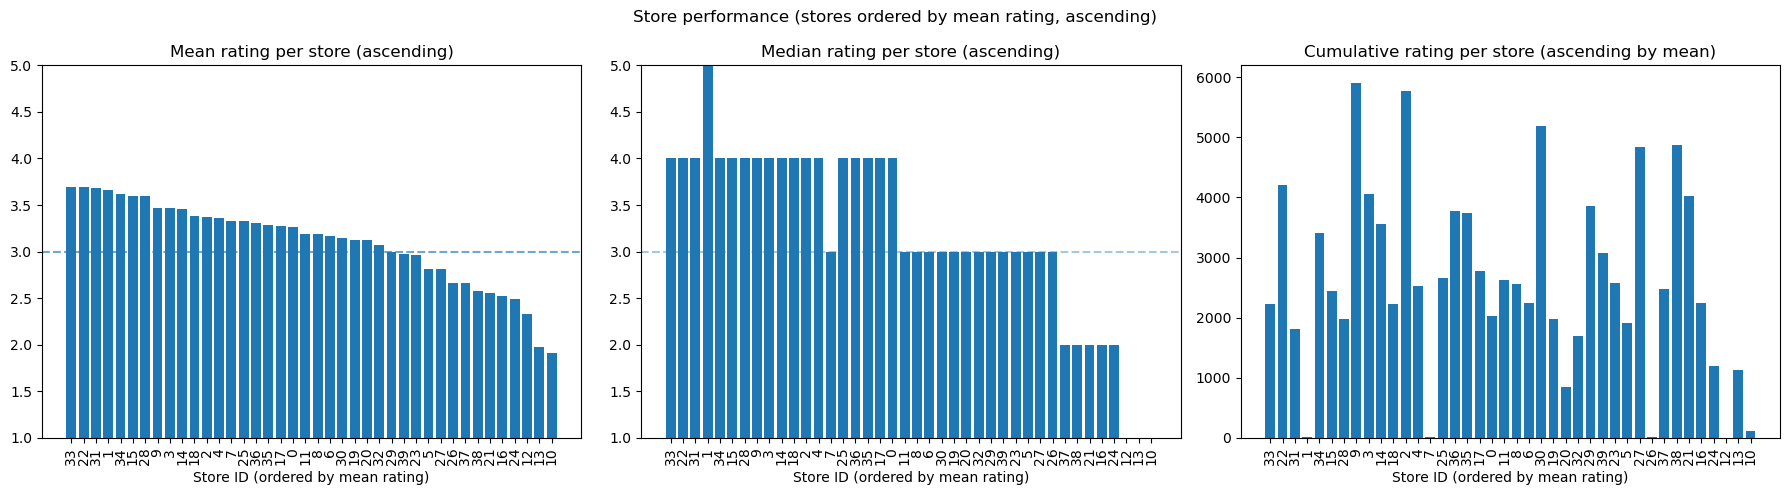

 Saved file ./store_perf_by_mean_median_cumulative_211225_23.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Mean rating
axes[0].bar(x, store_perf_sorted["mean_rating"])
axes[0].axhline(3, linestyle="--", alpha=0.4)
axes[0].set_title("Mean rating per store (ascending)")
axes[0].set_ylim(1, 5)

# Median rating
axes[1].bar(x, store_perf_sorted["median_rating"])
axes[1].axhline(3, linestyle="--", alpha=0.4)
axes[1].set_title("Median rating per store (ascending)")
axes[1].set_ylim(1, 5)

# Cumulative rating
axes[2].bar(x, store_perf_sorted["cumulative_rating"])
axes[0].axhline(3, linestyle="--", alpha=0.4)
axes[2].set_title("Cumulative rating per store (ascending by mean)")

# X-axis labels (sorted store IDs)
for ax in axes:
    ax.set_xlabel("Store ID (ordered by mean rating)")
    ax.set_xticks(x)
    ax.set_xticklabels(store_perf_sorted.index, rotation=90)

plt.suptitle("Store performance (stores ordered by mean rating, ascending)")
plt.tight_layout()
# call our save_file function
save_file('store_perf_by_mean_median_cumulative')
plt.show()


we get a quick overview comparison plot of all three, mean, median and cumulative


Store performance measured using mean, median, and cumulative ratings, highlighting differences between perceived quality and total customer feedback volume.

- 31, 32, 31 agree broadly across mean nd median 
- they do not agree with cumulative however. 
- Low sample count results in low rating performance. Perhaps put in place a metric for minimum number of reviews.
- Mean appears to provide a more stable calculation of performance.It takes account of all data and addresses variations due to sample size.
- Median provides a stable overview but appears less sensitive to gradual shifts in ratings, and a lot appear neutral at 3, or one step above or below. It displays more step wise behaviour.

2.1c - Tabular comparison of top 5 and worst 5 stores across mean, median and cumulative

In [41]:
# craete df for top 5 values based on mean rating
top_5_best = (store_perf_df.sort_values("mean_rating", ascending=False).head(5))

top_5_best


,mean_rating,median_rating,cumulative_rating,review_count
store_id,,,,
33,3.697674,4.0,2226,602
22,3.692105,4.0,4209,1140
31,3.687755,4.0,1807,490
1,3.666667,5.0,11,3
34,3.615058,4.0,3409,943


In [42]:
# craete df for bottom 5 values based on mean rating
bottom_5_worst = (store_perf_df.sort_values("mean_rating", ascending=True).head(5))

bottom_5_worst


,mean_rating,median_rating,cumulative_rating,review_count
store_id,,,,
10,1.916667,1.0,115,60
13,1.971930,1.0,1124,570
12,2.333333,1.0,7,3
24,2.492723,2.0,1199,481
16,2.525843,2.0,2248,890


Tabular comparison across mean and median and cumulatitive

In [43]:
# define columns we want to display
cols = ["mean_rating", "median_rating", "review_count", "cumulative_rating"]

top_5_best = top_5_best[cols].round(2)
bottom_5_worst = bottom_5_worst[cols].round(2)

print('=======  top 5 stores ==============\n')
print(f" top 5 stores = {top_5_best}")
print('=======  worst  5 stores ==============\n')
print(f" top 5 stores = {bottom_5_worst}")


=======  top 5 stores ==============

 top 5 stores =           mean_rating  median_rating  review_count  cumulative_rating
store_id                                                             
33               3.70            4.0           602               2226
22               3.69            4.0          1140               4209
31               3.69            4.0           490               1807
1                3.67            5.0             3                 11
34               3.62            4.0           943               3409
=======  worst  5 stores ==============

 top 5 stores =           mean_rating  median_rating  review_count  cumulative_rating
store_id                                                             
10               1.92            1.0            60                115
13               1.97            1.0           570               1124
12               2.33            1.0             3                  7
24               2.49            2.0           48

Overview of Results

- 33, 22, an 34 are performing well. Have relatively high rating count and above average rating numbers.
- 13, 16 and 24 are not performing well. Have relatively high rating count yet low mean_rating
- Store 10 haas a relatively low rating count, so more dat would be required to make a proper assessment of it, but initial feedback indicators are that it is not performing to a high level
- stores 1 and 12 have very low sample count, so this result unreliable for those stores
- As per earlier, low sample counts are affecting performance assessment.

2.1d - Plot of mean performance rating per store

Note: This still includes stored with low rating count

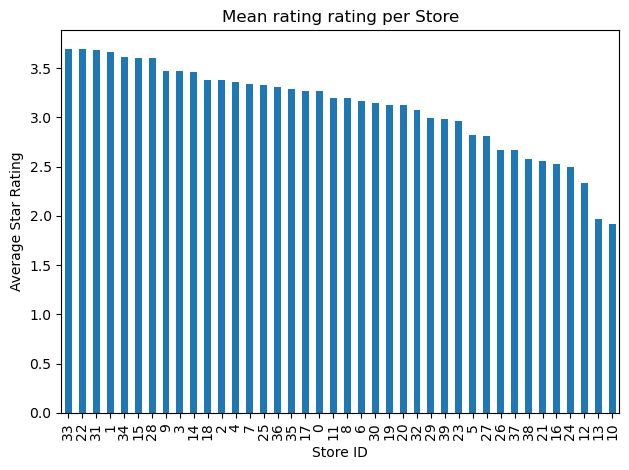

 Saved file ./mean_rating_per_store_211225_23.png


In [44]:
# will give averag rating per store... this will add up 
# How it calculates average .. add up al the ratigns and divide by number of ratings...
# thsi does tn take account of number of ratsing per store....
store_perf_mean_df = (mcd_df_1.groupby("store_id")["star_rating_num"].mean().sort_values(ascending=False))

# Plot average rating per store
plt.figure()
store_perf_mean_df.plot(kind="bar")
plt.title("Mean rating rating per Store")
plt.xlabel("Store ID")
plt.ylabel("Average Star Rating")
plt.tight_layout()
# call our save_file function
save_file('mean_rating_per_store')
plt.show()


Using this method of identifying the best store can lead to situation where store with a small number of reviews and a store with many reviews are treated equally and the same weight wis given to their cummulative totals. So the above may not be the best metric to identify the best performing store

2.1e - Plot of number of reviews per store

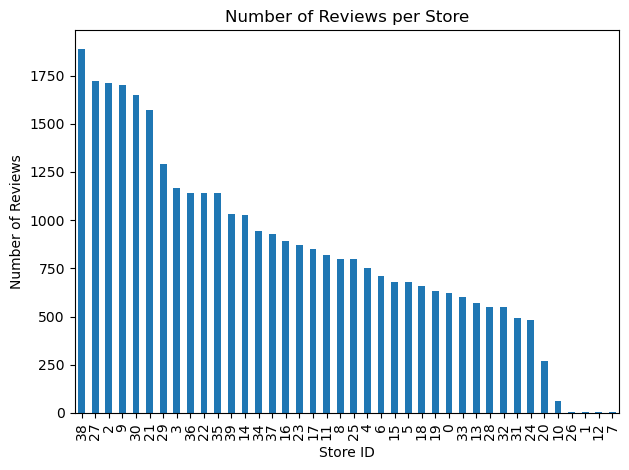

 Saved file ./number_of_reviews_per_store_211225_23.png


In [45]:
review_count_store = (mcd_df_1.groupby("store_id").size().sort_values(ascending=False))

plt.figure()
review_count_store.plot(kind="bar")
plt.title("Number of Reviews per Store")
plt.xlabel("Store ID")
plt.ylabel("Number of Reviews")
plt.tight_layout()
# call our save_file function
save_file('number_of_reviews_per_store')
plt.show()


BIg differenc e in viume of reviews per store ranging from 1750+ to 1. 

A store with an average ratign of 3.5 and 500 reviews has less weight as an accurate measure to a store with an average of 3.1 and 1500 reviews.

We must take account of the number of reviews when assessing the best performing stores.

2.1f - Plot of Ratings over derived time

Our time data is not intended to be a real reflection of time. It is derived from a backwards lok at a collecti time i.e. '1 day ago', '1 week ago', '2 years ago', etc  

It is intended purely to try give some level or ordering allowing to get some indication of relevance of data due to the large delta between the older and newest review.
 

view review data by year

In [46]:
mcd_df_1["review_relative_time"].dt.year.value_counts().sort_index()


review_relative_time
2013       4
2014      10
2015      38
2016      52
2017      91
2018     387
2019    1678
2020    4306
2021    6740
2022    5522
2023    3892
2024    4809
2025    5866
Name: count, dtype: int64

view review data by month

In [47]:
mcd_df_1["review_relative_time"].dt.to_period("M").value_counts().sort_index().head(15)


review_relative_time
2013-12       4
2014-12      10
2015-12      38
2016-12      52
2017-12      91
2018-12     387
2019-12    1678
2020-12    4306
2021-12    6740
2022-12    5522
2023-12    3892
2024-12    4809
2025-01     457
2025-02     503
2025-03     444
Freq: M, Name: count, dtype: int64

There is an issue with th derived time data. 

Reviews all appear in December. This is due to calculating backward from a fixed reference date of today. So we cannot get an accurate time frame for when reviews were received.

PLot agregatted by month

In [48]:
# aggregate by month
mcd_df_1["year_month"] = mcd_df_1["review_relative_time"].dt.to_period("M")
# montly aveage  using mean
monthly_avg = (mcd_df_1.groupby("year_month")["star_rating_num"].mean())

# create a new df to pltok from
monthly_avg_ts = monthly_avg.copy()
# convert the period index to timestamp
monthly_avg_ts.index = monthly_avg_ts.index.to_timestamp()



In [49]:
yearly = (mcd_df_1.groupby(mcd_df_1["review_relative_time"].dt.year).agg(avg_rating=("star_rating_num", "mean"),review_count=("star_rating_num", "size")))

# yearly.index = pd.to_datetime(yearly.index, format="%Y")


Plot of average ratings per year and rating volumes per year

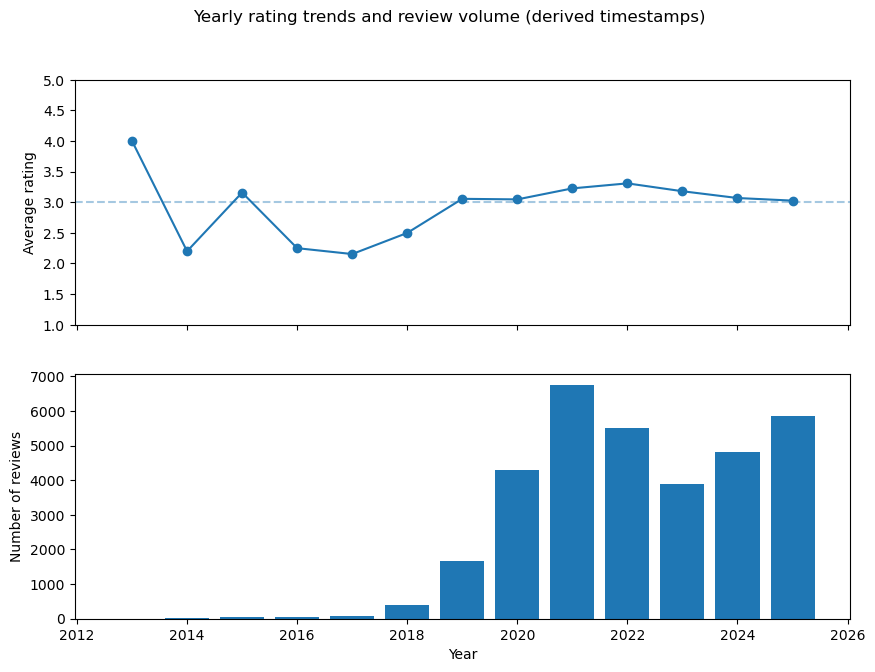

 Saved file ./yearly_rating_trends_and_review_volume_derived_times_211225_23.png


In [50]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(yearly.index, yearly["avg_rating"], marker="o")
axes[0].set_ylim(1, 5)
axes[0].axhline(3, linestyle="--", alpha=0.4)
axes[0].set_ylabel("Average rating")

axes[1].bar(yearly.index, yearly["review_count"])
axes[1].set_ylabel("Number of reviews")
axes[1].set_xlabel("Year")

plt.suptitle("Yearly rating trends and review volume (derived timestamps)")
# call our save_file function
save_file('yearly_rating_trends_and_review_volume_derived_times')
plt.show()


- Average rating dropped from approx 2017 to 2019
- Has hovered in or around neutral, i.e. 3.0  since then
- Additional time series plots were removed from the notebook as there wer elimited int here usefulness.
- These derived time values have their limitations and have accumulations of data around specific dates i.e. Dec every year dur to how w calculated the time.
- we will nto focus on time based data for further analyse as a result as limited data available and insight available from it.
- from 2012 to 2019 have very little review data
-  Most data is from 2020 onwards
- large variance in spread of and skewed to the right

2.2g - Plot of Likert Scale for ratings data

we will assusme Lickert likert scale of review star ratings, plot the values and see what they are like
i.e 

- 1 = very negative
- 2 =negative
- 3 = neutral
- 4 = positive
- 5 = very positive

We do not know if the rating values were presented as Likert scale values, as outlined above. OPur values are ordinal and we will assume Likert scale application to see how our data performs.

This may provide more insight than using mean, median or cumulative values. It is intended to provide general sentiment view and degree of sentiment.It may or may not be accurate.


Calculate the count values and percentage value for star ratings 1 to 5

In [51]:
# we'll create a df copy to work in
likert_df = mcd_df_1.copy()

# group the data by store id and rating, count number of rows in eacg group, then unstakc those valeus into columns
# so each ratign become sits own column, fill any missing values with 0
likert_df= (mcd_df_1.groupby(["store_id", "star_rating_num"]).size().unstack(fill_value=0))

# each row  = one store 
# each column = number of reviews at that star rating
# data is raw value counts
likert_df

likert_df = likert_df.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

# convert counts to percentages to allow stores be comparable and normalised, as various rating counts across stores
# cal percentage value per row, each storpe is one row and each columm is % of reveiws at that star level
# give spercentage sentiment profile for each store based on number of rating types
likert_pct_df = likert_df.div(likert_df.sum(axis=1), axis=0) * 100

# % per row total to 100%
likert_pct_df

star_rating_num,1,2,3,4,5
store_id,,,,,
0,21.612903,10.806452,17.096774,20.000000,30.483871
1,33.333333,0.000000,0.000000,0.000000,66.666667
2,22.514620,9.239766,13.859649,16.783626,37.602339
3,18.835616,8.390411,14.297945,24.315068,34.160959
4,20.106525,9.454061,17.443409,20.106525,32.889481
5,36.029412,10.441176,14.264706,14.264706,25.000000
6,30.704225,8.309859,11.126761,13.521127,36.338028
7,0.000000,0.000000,66.666667,33.333333,0.000000
8,25.375000,8.625000,17.875000,17.625000,30.500000


create groups for sentiment, aggregate values 1 + 2, and 3 for neutral and 4 + 5 for positive

In [52]:
# sum the perventages per sentiment grouping
likert_pct_df['negative'] = likert_pct_df[1] + likert_pct_df[2]
likert_pct_df['neutral'] = likert_pct_df[3] 
likert_pct_df['positive'] = likert_pct_df[4] + likert_pct_df[5]

print(likert_pct_df)

star_rating_num          1          2          3          4          5  \
store_id                                                                 
0                21.612903  10.806452  17.096774  20.000000  30.483871   
1                33.333333   0.000000   0.000000   0.000000  66.666667   
2                22.514620   9.239766  13.859649  16.783626  37.602339   
3                18.835616   8.390411  14.297945  24.315068  34.160959   
4                20.106525   9.454061  17.443409  20.106525  32.889481   
5                36.029412  10.441176  14.264706  14.264706  25.000000   
6                30.704225   8.309859  11.126761  13.521127  36.338028   
7                 0.000000   0.000000  66.666667  33.333333   0.000000   
8                25.375000   8.625000  17.875000  17.625000  30.500000   
9                19.823529   8.235294  14.705882  19.529412  37.705882   
10               60.000000  10.000000  16.666667   5.000000   8.333333   
11               24.024390  10.365854 

calculate net sentiment by subtracting the total negative sentiment from the positive sentiment

In [53]:
# sort the df
l1_df = likert_pct_df.sort_index()


# neutral_x = l1_df["neutral"].values
# # craete index values for plotting as mathplotlib uses original non-sorted values
# df.index is numeric store_id mathplotlob interprets numeric y valus as actual co-ordinates and not as row order.. so mathplotlib ignores ordering f the df and places bars at y - store_id
# we'll sue the store_id only as labels and deqiential positions for y
# thsi products a signle scalar nto a vecotr, a scakar ahs no length

y = np.arange(len(l1_df))

assert len(l1_df["neutral"]) == len(y)



PLot the groupings

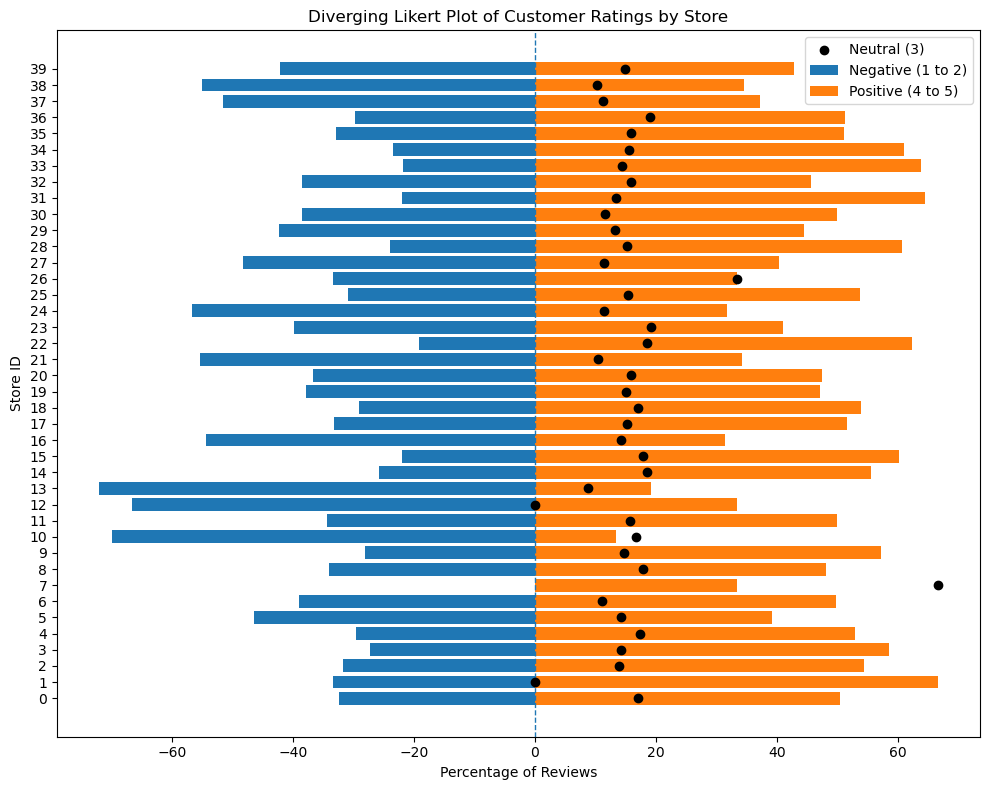

 Saved file ./divergent_likert_plot_cust_rat_per_store_211225_23.png


In [54]:
fig, ax = plt.subplots(figsize=(10, 8))

# negative plto to the left
ax.barh( y, -l1_df["negative"], label="Negative (1 to 2)")

# positive plot to thr right
ax.barh(  y, l1_df["positive"], label="Positive (4 to 5)")

# neutral dots
ax.scatter( l1_df["neutral"].values, y,  color="black", label="Neutral (3)",  zorder=3)
# ax.scatter( neutral_x, y, color="black", label="Neutral (3)",  zorder=3)

# the zero line
ax.axvline(0, linestyle="--", linewidth=1)

# axis labels and title
ax.set_xlabel("Percentage of Reviews")
ax.set_ylabel("Store ID")
ax.set_title("Diverging Likert Plot of Customer Ratings by Store")

# y-axis labels = store_id
ax.set_yticks(y)
ax.set_yticklabels(l1_df.index)

ax.legend()
plt.tight_layout()
# call our save_file function
save_file('divergent_likert_plot_cust_rat_per_store')
plt.show()

- Diverging Likert plot helps visualise the distribution of positive, negativue and neutral reviews to provide an overall sentiment per store.
- rating values were agregated at 1+2 = negative, 4+5 as positive and 3 = neutral.
- orange bars to the right hand side are positive review
- blue bars tp the left hand side are negative reviews
- black dots on bar are number of neutral reviews
- store_id = 7  - looks like anomaly
    - has 0 negative / 2 neutral  / 1 positive review = > as total pos/neg/neutral must = 100% = > neutral  = 66.6%
    - this is a result of a small sample size.
- Provides more direct and complete performance rating in comparison to performance rating using mean, median or cumulative



2.1h - Create word frequency count and word cloud

In [55]:

stopwords = set(nltk_stopwords.words('english'))
lemmatizer = WordNetLemmatizer()



Function to clean text

In [56]:
custom_stopwords= []
def clean_text_new(text, custom_stopwords=None):
    # handle missing values
    if pd.isna(text):
        return []

    # remove non-ascii characters
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # lower case
    text = text.lower()

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # remove digits
    text = re.sub(r"\d+", "", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    tokens = word_tokenize(text)
    
    # stopwords
    stop_words = set(nltk_stopwords.words("english"))
    if custom_stopwords:
        stop_words.update(custom_stopwords)

    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]

    # lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w, pos="v") for w in tokens]

    return tokens


In [57]:

word_count_df = mcd_df_1.copy()

# clean reviews
word_count_df["tokens"] = word_count_df["review"].apply(lambda x: clean_text_new(x, custom_stopwords))

# flatten tokens
all_words = [
    word
    for tokens in word_count_df["tokens"]
    for word in tokens
]

# count frequencies
bow_counts = Counter(all_words)

# convert to dataframe
bow_df = (
    pd.DataFrame(bow_counts.items(), columns=["word", "frequency"])
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

print(bow_df.head(20))


         word  frequency
0       order       9169
1        food       7783
2     service       6317
3         get       5939
4   mcdonalds       5737
5        good       5572
6          go       4570
7       place       3730
8        time       3465
9        wait       3171
10      drive       2995
11        one       2727
12       take       2713
13       fast       2706
14       like       2689
15      staff       2551
16  excellent       2536
17      great       2313
18     always       2295
19      clean       2199


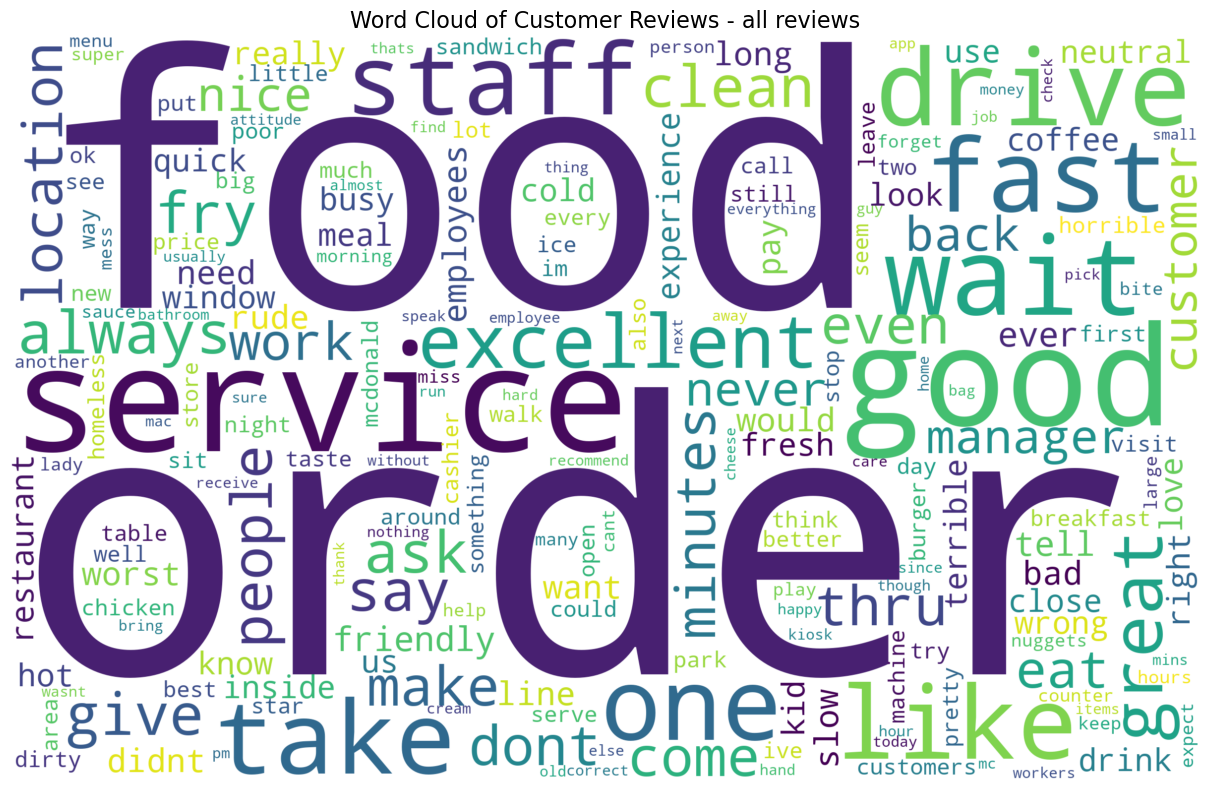

 Saved file ./word_cloud_all_words_all_reviews_211225_23.png


In [58]:
# list of words to remove which add nok reall value to determining sentient
remove_stopwords = ['mcdonalds', 'place', 'time', 'get', 'go']

bow_df_filtered = bow_df[~bow_df["word"].isin(remove_stopwords)]

# convert our word frequency df into a dict for plotting
word_freq = dict(zip(bow_df_filtered["word"], bow_df_filtered["frequency"]))


wc = WordCloud( max_words=200, background_color="white",  width=800,  height=500,  scale=3, relative_scaling=0.5,  random_state=42).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews - all reviews", fontsize=16)
plt.tight_layout()
# call our save_file function
save_file('word_cloud_all_words_all_reviews')
plt.show()


- count of frequencies of words present gives is bag of words
- frequencies were visualised where size represent proportino of occurence in reviews
- some example positive words are 'good', 'great', 'excellent', 'friendly', 'clean'
- some example negative words are 'bad', 'worst', 'rude', 'terrible', 'cold', 'mess'
- These frequencies were visualised using a word cloud, where word size is proportional to occurrence frequency after preprocessing and stop-word removal.

2.1i - Create positive and negative word lists and plot from 'star_rating _num' data

In [59]:
pos_reviews = mcd_df_1[mcd_df_1["star_rating_num"] >= 4]
neg_reviews = mcd_df_1[mcd_df_1["star_rating_num"] <= 2]


In [60]:
# apply remove_stopwords list at run time for functino aswell to reove those words also
pos_tokens = [w for tokens in pos_reviews["review"].apply(lambda x: clean_text_new(x, custom_stopwords=remove_stopwords)) for w in tokens]

neg_tokens = [w for tokens in neg_reviews["review"].apply(lambda x: clean_text_new(x, custom_stopwords=remove_stopwords)) for w in tokens]

# craete dictionary object with key value pairs of words and counts.
# use counter method from collections package
# https://docs.python.org/3/library/collections.html#collections.Counter
pos_counts = Counter(pos_tokens)
neg_counts = Counter(neg_tokens)

print(f" posotive words = {pos_counts}")
print(f" negative words = {neg_counts}")


 posotive words = Counter({'good': 4235, 'food': 3104, 'service': 2959, 'excellent': 2495, 'great': 1952, 'fast': 1940, 'order': 1846, 'clean': 1532, 'always': 1151, 'nice': 1149, 'friendly': 1136, 'staff': 1126, 'love': 960, 'like': 845, 'quick': 814, 'get': 685, 'fresh': 683, 'hot': 680, 'one': 668, 'location': 651, 'drive': 650, 'best': 617, 'eat': 576, 'fry': 568, 'make': 567, 'go': 540, 'people': 508, 'take': 473, 'come': 468, 'busy': 458, 'wait': 441, 'customer': 440, 'really': 432, 'kid': 426, 'work': 424, 'area': 420, 'thru': 412, 'coffee': 412, 'well': 409, 'breakfast': 393, 'even': 365, 'pretty': 361, 'restaurant': 361, 'experience': 355, 'give': 347, 'right': 341, 'line': 329, 'dont': 323, 'employees': 308, 'visit': 308, 'play': 303, 'inside': 300, 'need': 299, 'long': 298, 'lot': 296, 'little': 295, 'also': 295, 'thank': 295, 'price': 287, 'use': 283, 'know': 278, 'new': 273, 'big': 270, 'mcdonald': 269, 'table': 268, 'super': 265, 'want': 265, 'back': 262, 'say': 262, 'piz

In [61]:
#apply most_common buitl in counter method from collection package
# https://docs.python.org/3/library/collections.html
pos_common = pos_counts.most_common(20)
neg_common = neg_counts.most_common(20)

# create dataframe fom pos common objects created earlier
pos_df = pd.DataFrame(pos_common, columns=["word", "count"])
neg_df = pd.DataFrame(neg_common, columns=["word", "count"])


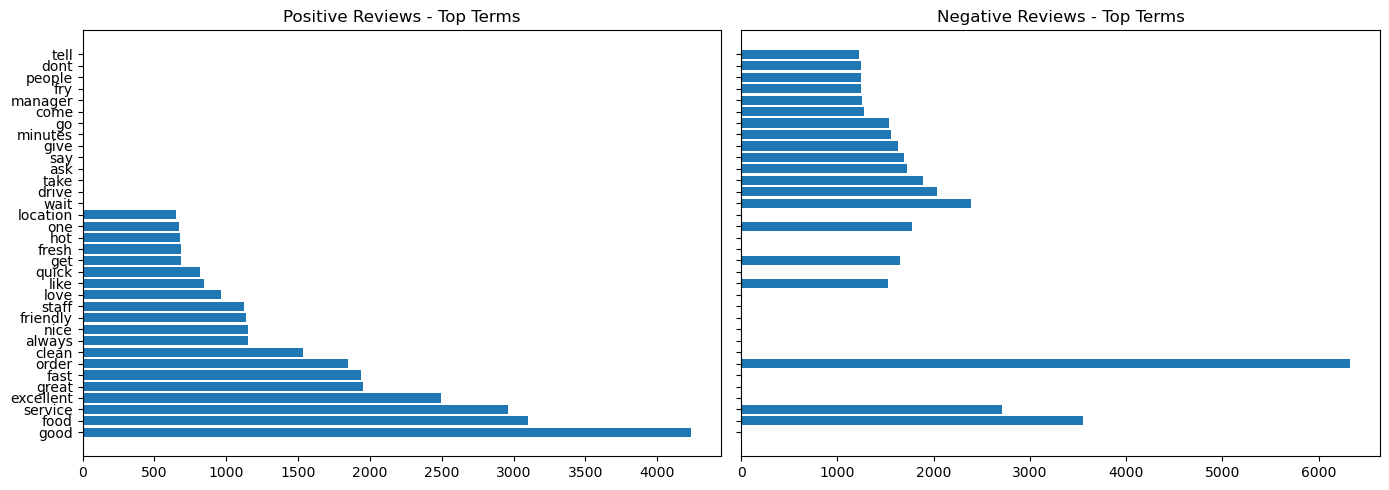

 Saved file ./pos_neg_reviews_top_terms_211225_23.png


In [62]:
# the dataframe of tope 20 ops and neg words and their counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].barh(pos_df["word"], pos_df["count"])
axes[0].set_title("Positive Reviews - Top Terms")

axes[1].barh(neg_df["word"], neg_df["count"])
axes[1].set_title("Negative Reviews - Top Terms")

plt.tight_layout()
# call our save_file function
save_file('pos_neg_reviews_top_terms')
plt.show()


- view of the most influential words in the corpus by frequency
- positive words i.e. 'good', 'excellent', 'fast', 
- negative words i.e. 'worst', 'rude', 'slow', 'wrong',
- neutral words which don't add sentient but are present in both positive and negative word lists i.e. 'food', 'service', 'order'
- sentiment comes from speed, cleanliness, staff, time  
- Confirms review data has valuable insight and is not random, and can build more sentiment analysis from it.
- 'food' and 'service' are the top occurring words in both positive and negative reviews, the key word alone will not indicate type of feedback, we need to star rating to apply that context.

### 2.2 - Visualise Review Embeddings using UMAP

For visualisation purposes we create a reduced tf-idf representation of review embeddings, using the same preprocessing pipeline as the modelling stage

review emneddings are numerical representations of the review text that capture patterns of word usage. review embedding here is a vector of numbers created from the review text using f-idf

In [63]:
# Text data for visualisation only (defined here to match notebook order)
X_texts_vis = mcd_df_1["review"].astype(str)
# create a tf-idf here for visualisation purposes only
# we will crete properly agai later for modelling
tfidf_vis = TfidfVectorizer( max_features=1000, min_df=5,  max_df=0.7,  stop_words="english")

X_tfidf_vis = tfidf_vis.fit_transform(X_texts_vis)


c:\Users\eamon\anaconda3\envs\assignment-a\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


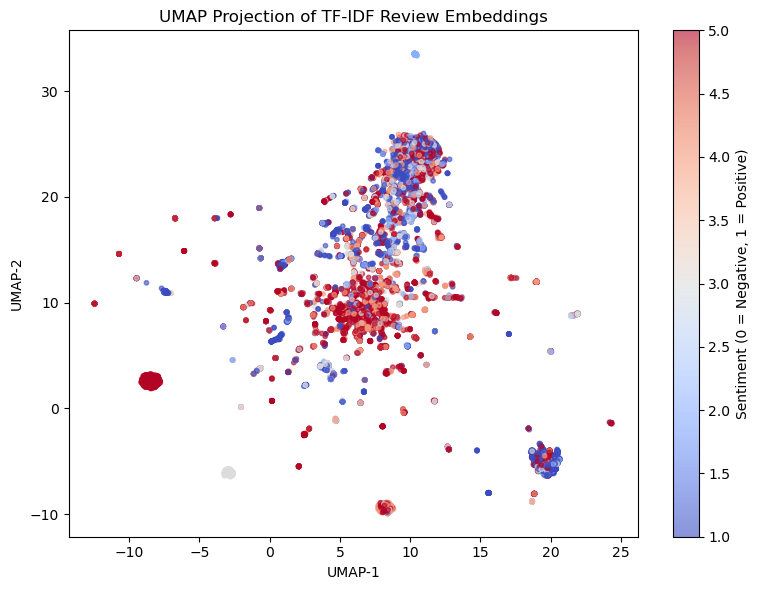

 Saved file ./umap_project_of_tf-idf_review_words_211225_23.png


In [64]:
# Sentiment labels aligned with visualisation data
y_vis = mcd_df_1["star_rating_num"].astype(int)

# reduce dimensionality for visualisation
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

X_umap = umap_model.fit_transform(X_tfidf_vis)

#X_umap = umap_model.fit_transform(X_tfidf)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter( X_umap[:, 0], X_umap[:, 1], c=y_vis, cmap="coolwarm", alpha=0.6, s=10)
plt.title("UMAP Projection of TF-IDF Review Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="Sentiment (0 = Negative, 1 = Positive)")
plt.tight_layout()
# call our save_file function
save_file('umap_project_of_tf-idf_review_words')
plt.show()


The UMAP projection of TF–IDF review embeddings reveals the structure within the review corpus when coloured by binary sentiment. 
- was configured with 15 nearest neighbours (n_neighbours=15), min distance = 0.1(min_dist-0.1), and two output dimensions
- Positive and negative reviews show partial clustering, 
- shows that sentiment information is captured within the high-dimensional TF–IDF feature space.
- Several dense regions are visible where one sentiment class dominates, 
- There is also overlap between classes, particularly in the central region of the plot. 
- This likely reflects reviews containing mixed sentiment, neutral language, or context-dependent terms (e.g. words such as “food” or “service” 

- Small number of isolated clusters and outliers are also visible. 
- These may correspond to unusually short reviews, highly repetitive phrases, or reviews containing uncommon vocabulary, all of which can lead to distinct TF–IDF representations. 

- Each dot in the UMAP plot = one review’s TF–IDF embedding

Overall, the plot supports the quantitative modelling results i.e. while sentiment is not perfectly separated there is sufficient structure for linear classifiers to achieve predictive outcomes.

High Analytical Value
- 'reviewer_id' - ou primary key, allows for unique reviewer per row data, prevents duplication and allows reviewer aggregation.
- 'review' - contains actual review text. essential for further analysis and NLP tasks. 
- 'star_rating_num' - essential to provide context and sentiment for text review data. 
- 'store_id' - allows for review per store and comparisons between stores 

These variables are retained in the dataframe as they are core to future analysis

Limited Analytical value
- 'review_relative_time' - derived time values, as such limited use for detailed proper time series analysis. Encountered issues around clustering of times around December, so accuracy is questionable outside of yearly time frame.
- 'lattitude' and 'longitude' - potential value if can include soe spatial/geolocatin analysis. 
- 'city' - medium value to aggregate data by city 
- 'state' -  medium value to aggregate data by state 

These variables while they are nto included in initial modelling dataframe in stage 3, they are available in case of future usage requirements


Low Analytical value
- 'store_address' - in its current form not a huge amount of analytical value. parsed it out into its constituent components which may have some value.
- 'street_number - limited value as have 'store_id' as unique id for stores now. May provide some use later
- 'street_name' - limited value as have 'store_id' as unique id for stores now. May provide some use later
- 'country'- no analytical value. No variation in the data, just a single data value.
- 'category' - no analytical value. No variation in the data.
- 'store_name' - no analytical value. No variation in the data.
- 'rating' - low analytical value now as mixed alphanumeric and have derived 'star_rating_num' column now.
- 'review_time' - low analytical value now as mixed alphanumeric and have derived 'review_relative_time' column now.

These variables are removed form the dataframe o reduce noise and dimensions.

Determination of how valuable colmsn was evidence based.
- assessment of dtypes and variable meaning
- numerical and categorical data exploration
- quantity of data oer column
- variety of data (umber of unique of values)
- level of corruption present 
- missing values
- plots and statistical analysis
- where data wasn't clean, derived new columns were created which were more easily usable in analsis such as 'store_id' and 'star_rating_num' 

## Step 3. Model Building and Evaluation (20 points)

3.1  - Details of Algorithms & Configurations

- Input features
    - Text features derived from review (Bag-of-Words, TF-IDF)
    - Aggregated store-level sentiment indicators
- Target variable
    - star_rating_num (binary or multi-class sentiment)

This dimensionality reduction ensures models are trained on high-signal, low-noise features, improving interpretability and performance.

Models
we will look at 
- Logistic Regression
    - Baseline, interpretable model
    - Configurations:
        - max_iter=1000
        - Regularisation (L2)
    - Naive Bayes (Multinomial)
        - Well-suited to word-count and TF-IDF features
        - Assumes feature independence (not realistic, but effective)
    - Support Vector Machine (Linear SVM)
        - Strong performance on high-dimensional text data
        - Effective margin-based classifier


3.1a - Prepare and validate the Dataset

In [65]:
# craete our workign dataframe
mcd_df_3 = mcd_df_1.copy()

cols_df_3 = ['reviewer_id', 'review', 'star_rating_num','store_id']

mcd_df_3 = mcd_df_3[cols_df_3]

# path defined at start of file, will save in same folder as this file
# save Stage 3 core modelling dataframe for Orange
output_file = f"{path}mcd_df_3_step3.csv"

# specify unicode encoding so as not to corrupt any characters as earleir
mcd_df_3.to_csv(output_file, index=False, encoding="utf-8")


print(f"Saved file to: {output_file}")

mcd_df_3
    


Saved file to: ./mcd_df_3_step3.csv


,reviewer_id,review,star_rating_num,store_id
0,1,Why does it look like someone spit on my food?...,1,8
1,2,It'd McDonalds. It is what it is as far as the...,4,8
2,3,Made a mobile order got to the speaker and che...,1,8
3,4,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5,8
4,5,"I repeat my order 3 times in the drive thru, a...",1,8
...,...,...,...,...
33391,33392,They treated me very badly.,1,21
33392,33393,The service is very good,5,21
33393,33394,To remove hunger is enough,4,21
33394,33395,"It's good, but lately it has become very expen...",5,21


verify mcd_df_3 dataframe structure and data

In [66]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# mcd_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , mcd_df_3.shape[0])
print ("Columns  : " , mcd_df_3.shape[1])
print('------')
print ("\nFeatures : \n" , mcd_df_3.columns.tolist())
print('------')
print ("\nMissing values :  ", mcd_df_3.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", mcd_df_3.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(mcd_df_3.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", mcd_df_3.nunique())
print('------')
print('\n null values = ', mcd_df_3.isnull().values.any())
print('------')
mcd_df_3_missing = (mcd_df_3 =='?').sum()
print('\"  ?   \" values present =  \n',mcd_df_3_missing)
print('------')
mcd_df_3_unknown = (mcd_df_3 =='unknown').sum()
print('\"   unknown   \" values present =  \n',mcd_df_3_unknown)
print('------')
mcd_df_3_na = mcd_df_3.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', mcd_df_3_na)
print('------')
mcd_df_3_none = mcd_df_3.isin(['None', 'none']).sum()
print('    none    values present = \n', mcd_df_3_none)
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
print('------')
mcd_df_3_rogue_ascii_df = mcd_df_3.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", mcd_df_3_rogue_ascii_df)

Rows     :  33395
Columns  :  4
------

Features : 
 ['reviewer_id', 'review', 'star_rating_num', 'store_id']
------

Missing values :   0
------

Missing values per column:   reviewer_id        0
review             0
star_rating_num    0
store_id           0
dtype: int64
------

num of dups in df   =   0
------

Unique values :  
 reviewer_id        33395
review             22284
star_rating_num        5
store_id              40
dtype: int64
------

 null values =  False
------
"  ?   " values present =  
 reviewer_id        0
review             0
star_rating_num    0
store_id           0
dtype: int64
------
"   unknown   " values present =  
 reviewer_id        0
review             0
star_rating_num    0
store_id           0
dtype: int64
------
    NA     values present = 
 reviewer_id        0
review             0
star_rating_num    0
store_id           0
dtype: int64
------
    none    values present = 
 reviewer_id        0
review             0
star_rating_num    0
store_id       

- shape = (33395, 4)
- no duplicates
- no missing values
- one row per review
- no 'none', 'na', 'unknown', '?' in any columns
- Unique values are as expected 
    - 'reviewer_id' =  33395
    - 'review' =   22284
    - 'star_rating_num'  =   5
    - 'store_id' =   40
- there are 3037 non-ascii characters present in the 'review' text. Not corruption or missing data. 

3.1b - Perform log ratio comparison to identify words associated with positive and negative reviews and plot results

In [67]:
# will sue math.log function to calculate ratio values, ths wil help balance large count differences
#which words re the most associated with negative sentiment
# which words are most associated wutb positive sentiment
# use sets to id all unique words in each and unino of both sets =? get every word that appears in both sets
all_words = set(pos_counts) | set(neg_counts)

# emoty list for word sentiment
word_sentiment = []

#loop through all words
for w in all_words:
    # how often word appears in pos reviews, if doesn't exist return zero
    pos = pos_counts.get(w, 0)
    # hwo often word appear in negative reviews
    neg = neg_counts.get(w, 0)
    #get a log value add +1 to avoid dividing by zero (is = > log ( pos count +1 / neg count +1)
    # > 0 pos review words / < 0 wneg review words / = 0 neutral words (appears in both)
    score = math.log((pos + 1) / (neg + 1))
    # store sall results for word asa  tuple
    word_sentiment.append((w, pos, neg, score))
# convert word tule into a dataframe, name the coliumns and sort by log por/neg ratio
# top rows most negative words
# bottom rows mos positive words
sentiment_word_df = (pd.DataFrame( word_sentiment, columns=["word", "pos_count", "neg_count", "log_pos_neg_ratio"]).sort_values("log_pos_neg_ratio"))



In [68]:
print('==== neg -  head words - top of df ======\n')
print(f" neg head words  = {sentiment_word_df.head()}")
print('\n==== npos -  tail words - bottom of df ======\n')
print(f" pos tail words  = {sentiment_word_df.tail()}")


==== neg -  head words - top of df ======

 neg head words  =                 word  pos_count  neg_count  log_pos_neg_ratio
9653           worst         11       1176          -4.585817
6761   disrespectful          0         88          -4.488636
6804            poor          6        609          -4.467549
11243       response          0         63          -4.158883
2421     disapointed          0         62          -4.143135

==== npos -  tail words - bottom of df ======

 pos tail words  =              word  pos_count  neg_count  log_pos_neg_ratio
2959          yum         25          0           3.258097
9899    fantastic         55          1           3.332205
6087   affordable         28          0           3.367296
10283   wonderful         78          0           4.369448
9329    excellent       2495         21           4.731402


PLot of top 10 negative and top 15 positive words

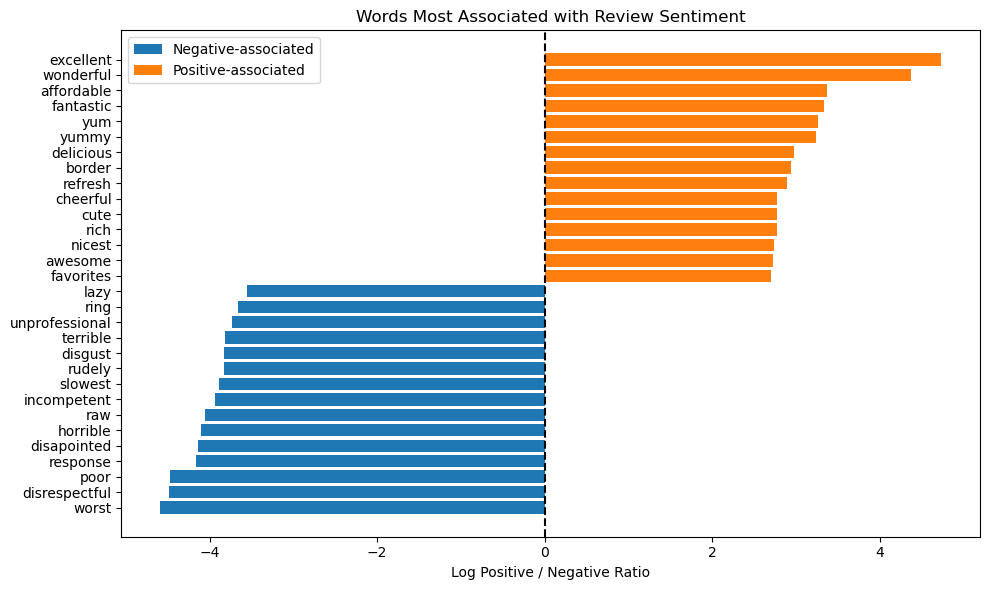

 Saved file ./words_most_associated_with_review_sentiment_211225_23.png


In [69]:
# take the top 10/15/20 words
top_neg = sentiment_word_df.head(15)
top_pos = sentiment_word_df.tail(15)


plt.figure(figsize=(10, 6))

# negative words
plt.barh( top_neg["word"], top_neg["log_pos_neg_ratio"], label="Negative-associated",)

# positive  words
plt.barh( top_pos["word"], top_pos["log_pos_neg_ratio"],  label="Positive-associated",)

# neutral bounddary between words
plt.axvline(0, color="black", linestyle="--")

plt.xlabel("Log Positive / Negative Ratio")
plt.title("Words Most Associated with Review Sentiment")
plt.legend()
plt.tight_layout()
# call our save_file function
save_file('words_most_associated_with_review_sentiment')
plt.show()


- A log ratio analysis used to identify exlusively positive words and exclusively negative words
- negative words drive complaints 
- positive words drive customer satisfaction
- '4.5'to '0' =  word appears in negative reviews. The higher the value the more associated with negative reviews the word is. This is a relative number
- 0 = word appears equally in both positive and negative reviews i.e. 'food', 'service'
- '0' to '4.5' = word appears in positive reviews. The higher the value the more associated with negative reviews the word is. This is a relative number
- Some words imply specific actions such as staff behaviour, customer service, service times, food quality, cost
- customer service or staff behaviour appears to be one of the biggest drivers of customer disastisfaction with words such as 'disrespectful', 'response','incompetent', 'slowest', 'rudely' , 'unprofessional', 'lazy' appearing strongly in the negative review words. 

3.1c - Prepare for and run supervised learning with a binary sentiment scenario and a TF–IDF vectorised Logistic Regression model

define the feature and target variables

In [70]:
# review text is the feature set contains raw text
X_texts = mcd_df_3["review"] 
# star_rating_num is the target label, contains sentiment signal/context
y_raw = mcd_df_3["star_rating_num"]


Crate Binary sentiment model  - Remove neutral rating 

In [71]:
# keep only negative (1–2) and positive (4–5)
# remove neutral rating 3 so we onl ahve 1-2 and 4-5 remaining
# y_arw is panda series perforsm vector comparison on each element to create bool series
# apply int type to that boolean so get oens and zeros
mask = y_raw != 3
print('===class distribution =====')
print(y_raw.value_counts())

# we keep x and y aligned, apply our mask to both, no leakage or mismatches
X_texts = X_texts[mask]
y_raw = y_raw[mask]

print('=== X_texts - review text =====\n')
print(X_texts)
print('=== y_raw - panda series =====\n')
print(y_raw)


===class distribution =====
star_rating_num
5    10274
1     9431
4     5787
3     4818
2     3085
Name: count, dtype: int64
=== X_texts - review text =====

0        Why does it look like someone spit on my food?...
1        It'd McDonalds. It is what it is as far as the...
2        Made a mobile order got to the speaker and che...
3        My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...
4        I repeat my order 3 times in the drive thru, a...
                               ...                        
33391                          They treated me very badly.
33392                             The service is very good
33393                           To remove hunger is enough
33394    It's good, but lately it has become very expen...
33395                            they took good care of me
Name: review, Length: 28577, dtype: object
=== y_raw - panda series =====

0        1
1        4
2        1
3        5
4        1
        ..
33391    1
33392    5
33393    4
33394    5
33395   

Convert to binary sentiment labels

In [72]:
# binary sentiment: 1 = positive (4–5), 0 = negative (1–2)
# 3 removed erlier so only values left are 1, 2 and 4 and 5
# there fore 1, 2 = > 0 negative and 4, 5 => 1 positive
# if greater than or equal to 4 get True = > 1
# condition not met =? False => 0
y = (y_raw >= 4).astype(int)

print(y)

0        0
1        1
2        0
3        1
4        0
        ..
33391    0
33392    1
33393    1
33394    1
33395    1
Name: star_rating_num, Length: 28577, dtype: int32


Verify objects and data output is as expected i.e. binary sentiment

In [73]:
# get the count of values for y
print('==== y value counts - class distribution =====')
print(y.value_counts())


# unique values of 1 and zero as per earlir
print('==== y unique values =====')
print("\nUnique labels:", y.unique())


==== y value counts - class distribution =====
star_rating_num
1    16061
0    12516
Name: count, dtype: int64
==== y unique values =====

Unique labels: [0 1]


- 0 = negative reviews, which is 1 and 2 stars
- 1 = positive rveiews, which is 4 and 5 stars
- 3 = neutral has been removed
- binary values now present in dataset

Create train / test split

In [74]:
# use 80/20 slpit fopr test/traimg data sizes
# randome_state -42 just a default value, left as is
# statify = y ?

X_train, X_test, y_train, y_test = train_test_split(X_texts, y, test_size=0.2, stratify=y, random_state=42)

print(f'Train size  = {X_train.shape[0]}')
print(f'Test size  = {X_test.shape[0]}')

Train size  = 22861
Test size  = 5716


Create Logistic regression pipeline to convert the text to numeric feature using TF-IDF then apply model

In [75]:
# transform the text using tfidf vectorisation to prevent data leakage
# wrap eerything in apipeline instead of manually vectorising first
# fit and transform the data
# term frequency - inverse document frequncy tf-idf *highlights words nia  review btu are rare across all reviews
# get high tf-if score if word appears often in a specific row but not in most other reveiws
# select the classifier - clf - Logisticregressin
pipeline_lr = Pipeline([("tfidf", TfidfVectorizer( max_features=1000, min_df=5, max_df=0.7 )),("clf", LogisticRegression( max_iter=1000,
        class_weight="balanced"))])



fit the train / test data to the pipeline

In [76]:
# train the model in memory
# returns a fitted pipeline object
pipeline_lr.fit(X_train, y_train)

# view pipeline - tf-idf runs first the logistic regressino second
print(pipeline_lr)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.7, max_features=1000, min_df=5)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


Evaluate the model using 5 fold cross validation  on training data to estimate performance

In [77]:
# use stratifiedkfold in binary sentiment  
# will tina the model multipel times i.e. k - 5, for evaulataion i.e. splits traingin data into folds
# does nto priduce a final trained model, evaluation only, 
# so fine tirun after mdoel fitting in previosuj cell
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# clones the earlier trained model pipeline_lr, ignores the fitted state
# spit the traingin data into folds and train the model inside each fold
# evaluates them then discards them
# cv only touches training data
cv_scores = cross_val_score(pipeline_lr,X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1)

print("CV ROC AUC scores:", cv_scores)
print("Mean CV ROC AUC:", cv_scores.mean())


CV ROC AUC scores: [0.96240862 0.96581784 0.96443974 0.96488296 0.96537998]
Mean CV ROC AUC: 0.9645858285975002


Result:

- A TF–IDF vectorised Logistic Regression model achieved a mean ROC AUC of 0.965 under 5-fold stratified cross-validation, indicating strong discriminative performance between positive and negative reviews.

Evaluate test set

In [78]:

y_test_proba = pipeline_lr.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC AUC:", test_auc)


Test ROC AUC: 0.9658421099162797


When given a random positive review and a random negative review from unseen data, your model correctly ranks the positive one higher about 96.6% of the time.



3.1d - Perform 'Naive Bayes', 'Linear SVM' and 'SGD Logistic' modelling on our binary sentiment data

Vectorise data using using TF-IDF in a pipeline for oru 3 additional models

In [79]:
pipeline_nb = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=1000, min_df=5, max_df=0.7)),
    ("clf", MultinomialNB())
])

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=1000, min_df=5, max_df=0.7)),
    ("clf", LinearSVC(class_weight="balanced"))

])

pipeline_sgd = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=1000, min_df=5, max_df=0.7)),
    ("clf", SGDClassifier(
        loss="log_loss",      # logistic regression
        class_weight="balanced",
        random_state=42 ))
])

 Cross-validation comparison (ROC AUC)

In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# craete a dictin to put models in their pipelines for key valeu pairs
models = {
    'Logistic Regression': pipeline_lr,
    'Naive Bayes': pipeline_nb,
    'Linear SVM': pipeline_svm,
    'SGD Logistic': pipeline_sgd
}

# create empty results list
results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "Mean ROC AUC": scores.mean(),
        "Std ROC AUC": scores.std()
    })

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Mean ROC AUC  Std ROC AUC
0  Logistic Regression      0.964586     0.001183
1          Naive Bayes      0.956628     0.001744
2           Linear SVM      0.964096     0.001081
3         SGD Logistic      0.962949     0.001695


3.1e - PLot ROC Curves all together - Logistic Regression, 'Naive Bayes', 'Linear SVM', 'SGD Logistic'

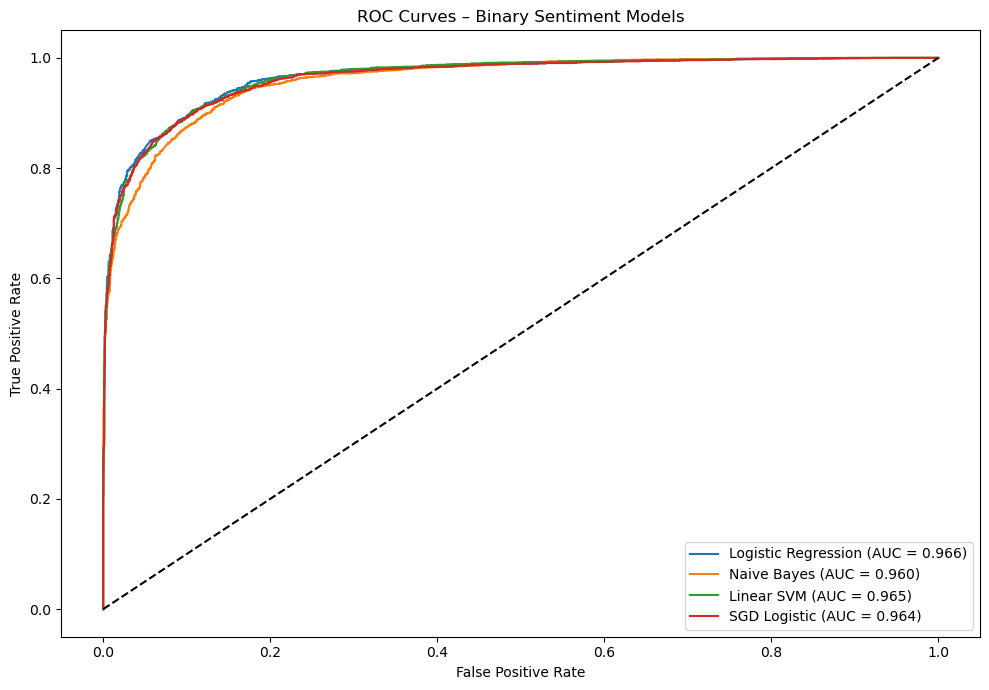

 Saved file ./roc_curve_4_models_bi_sentiment_211225_23.png


In [81]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        # LinearSVC
        y_score = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Binary Sentiment Models")
plt.legend()
plt.tight_layout()
# call our save_file function
save_file('roc_curve_4_models_bi_sentiment')
plt.show()


ROC Curve tells us the probability that a randomly selected positive review is ranked higher than a randomly selected negative review.
- AUC Results:
    - Logistic Regression = 0.966 (96.6%)
    - Linear SVM = 0.965 (96.5%)
    - SGD Logistic = 0.964 (96.4%)
    - Naive Bayes = 0.960 (96%)

- Logistic Regression and Linear SVM perform very similar, LR performs just slightly better
- SGD Logistic is next best
- Naive Bayes performs worst but is still not too bad.
- Models were fast processing. taking < 1 min to complete the train and less on the test data.

- Data Insight
    - There is strong sentiment data present in the review text
    - Word usage can provide good predictive outcomes  
    - Confirms decisions made earlier during cleaning and exploration phases with the data set.

3.1f - Generate confusion matrix for all 4 models

In [82]:
# loop througn the mdoel name list
for name, model in models.items():
    
    # fit model - train model on traingin data
    model.fit(X_train, y_train)
    
    # Predict using consistent decision rules
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= 0.5).astype(int)
    else:
        # Linear SVM
        y_scores = model.decision_function(X_test)
        y_pred = (y_scores >= 0).astype(int)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print('========================================')
    print(f"\nConfusion Matrix  {name}")
    print("Rows = True labels, Columns = Predicted labels")
    print("          Pred 0    Pred 1")
    print(f"True 0    {cm[0,0]:6d}  {cm[0,1]:6d}")
    print(f"True 1    {cm[1,0]:6d}  {cm[1,1]:6d}")



Confusion Matrix  Logistic Regression
Rows = True labels, Columns = Predicted labels
          Pred 0    Pred 1
True 0      2284     219
True 1       387    2826

Confusion Matrix  Naive Bayes
Rows = True labels, Columns = Predicted labels
          Pred 0    Pred 1
True 0      2252     251
True 1       404    2809

Confusion Matrix  Linear SVM
Rows = True labels, Columns = Predicted labels
          Pred 0    Pred 1
True 0      2257     246
True 1       356    2857

Confusion Matrix  SGD Logistic
Rows = True labels, Columns = Predicted labels
          Pred 0    Pred 1
True 0      2304     199
True 1       423    2790


Confusion Matrix Results:

- Confusion matrix provides raw data on correct and incorrect actions that the models performed
- Logistic Regression (This is our best performing predictive model)
    - high TN (2284) and TP (2826) values
        - TN = model predicted 2284 reviews were Negative sentiment when were negative sentiment - model was correct
        - TP = model predicted 2286 reviews were Positive sentiment when were positive sentiment - model was correct
    - similar values for FN (387)  and FP (219)
        - FN = model predicted 387 reviews were Negative sentiment when were positive sentiment - model was incorrect
        - FP = model predicted 219 reviews were Positive sentiment when it was negative sentiment - model was incorrect 
- Liner SVM
    - high TN (2257) and TP (2857) values
        - TN = model predicted 2257 reviews were Negative sentiment when were negative sentiment - model was correct
        - TP = model predicted 2857 reviews were Positive sentiment when were positive sentiment - model was correct
    - similar values for FN (356)  and FP (246)
        - FN = model predicted 356 reviews were Negative sentiment when were positive sentiment - model was incorrect
        - FP = model predicted 246 reviews were Positive sentiment when it was negative sentiment - model was incorrect 
- SGD Logistic
    - high TN (2304) and TP (2790) values
        - TN = model predicted 2304 reviews were Negative sentiment when were negative sentiment - model was correct
        - TP = model predicted 2709 reviews were Positive sentiment when were positive sentiment - model was correct
    - similar values for FN (423)  and FP (199)
        - FN = model predicted 423 reviews were Negative sentiment when were positive sentiment - model was incorrect
        - FP = model predicted 199 reviews were Positive sentiment when it was negative sentiment - model was incorrect 
- Naive Bayes
    - high TN (2252) and TP (2809) values
        - TN = model predicted 2252 reviews were Negative sentiment when were negative sentiment - model was correct
        - TP = model predicted 2809 reviews were Positive sentiment when were positive sentiment - model was correct
    - similar values for FN (404)  and FP (251)
        - FN = model predicted 404 reviews were Negative sentiment when were positive sentiment - model was incorrect
        - FP = model predicted 251 reviews were Positive sentiment when it was negative sentiment - model was incorrect 

- Worst outcome is probably in predicting False Positive (FP) - as this results in the missing important negative feedback which could require immediate action.

- SGD Logistics has lowest number of FPs at 199

3.1g - Generate 'Precision', 'Recall' and 'F1' matrix for all 4 models

In [83]:
# loop through model name and pipeline from model dictinary we create earlier - key value pairs
for name, model in models.items():
    # train the pipeline ont he traigin data
    # applying tfidf and clf .fit on tfidf features
    # craetes final trained mdoel for evaluation
    # this trainign is separate fomr cross validation oeformed earlier
    model.fit(X_train, y_train)
    # check if model supports probability predictions
    #linear svm does ntok support probability predictins the otehrs do
    if hasattr(model, "predict_proba"):
        # gets predicted probabilites for positive class col 0 = (class 0 -  negative) and col 1 (clas 1  - positive)
        # y_scores is a vecotr of confidence values between 0 and 1
        y_scores = model.predict_proba(X_test)[:, 1]
        # specifies a decisin threshold value
        # if prob >= 0.5 => positive ie. 1
        # otherise =>negative i.e. 0
        y_pred = (y_scores >= 0.5).astype(int)
    else:
        # to handle linear svmwhchih doesn' support probabilites
        y_scores = model.decision_function(X_test)
        # same >- 0 => positive
        # < 0 => negative
        y_pred = (y_scores >= 0).astype(int)
    
    # functions from the sklearn.metrics package to get evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n===== {name} =======")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")



===== Logistic Regression =======
Precision: 0.928
Recall:    0.880
F1 Score:  0.903

===== Naive Bayes =======
Precision: 0.918
Recall:    0.874
F1 Score:  0.896

===== Linear SVM =======
Precision: 0.921
Recall:    0.889
F1 Score:  0.905

===== SGD Logistic =======
Precision: 0.933
Recall:    0.868
F1 Score:  0.900


Results for Precision, Recall and F1 score

- 'Precision' - how accurate model is in terms positivity i.e. predicts positive it is positive - high or low value.
- 'Recall' - catches most positive reviews i.e. how many positive reviews does it miss - high or low value
- 'F1' - single balance metric  - useful if neither FP or FN dominates

- Best Precision
    - SGD Logistic = .933
    - Logistic Regression = 0.928
    - Linear SVM = 0.921
    - Naive Bayes = 0.918
- Best Recall
    - Linear SVM = 0.889
    - Logistic Regression = 0.880
    - Naive Bayes = 0.874
    - SGD Logistic = .868
- Best F1
    - Linear SVM = 0.905
    - Logistic Regression = 0.903
    - SGD Logistic = .900
    - Naive Bayes = 0.896


- Linear SVM has best 'Precision' and 'F1' scores and 
- SGD Logistic has best 'Precision' scores
- Logistic regression is second in all categories
- Linear SVM is 3rd in 'Precision'
- SGD Logistic 3rd in 'F1' and 4th in 'Recall'
- Naive Bayes is 3rd or 4th across all 3 metrics


3.1h - Best Model Choice Analysis

- Minimise FPs  = SGD Logistic
- best Balance = Linear SVM
- Performance = Logistic Regression 
- Interpretability i.e. hwo explainable is the result i.e  why did we get a predicted outcome = Logistic regression 9as uses co-efficients for ach word we cna access easily enough)

If minimizing False Positives is the most important goal, SGD Logistic is the best model choice. This would depend on what data we aer looking for and what action may be taken off that data i.e. food cleanliness issue is flagged and food safety has to be undertaken immediately to prevent illness in a restaurant. 

This would require further business discussion about how the feedback model would be used befor a final decision is taken.

If overall performance id the most important metric and interpretability is important to the business, why did we get an outcome, Logistic Regression may be the best model choice. i.e. a staff member is accused of an action in feedback, hwo was that flagged as an issue? or we need traceability in our predictions. 

Again this is a business dicussion before a final decision can be taken.

## 4. Advanced Techniques and Analysis (20 points)

### 4.1 Clustering of review Embeddings using K-means 

To complement the supervised sentiment models performed earlier, unsupervised clustering is applied here to explore whether reviews naturally group by sentiment without labelled data

review embedding here is a vector of numbers created from the review text using f-idf

In [84]:
# K-Means clustering - unsupervised exploratory used to view structure
# split the data into 2 clusters - i.e. binary sentiment
# ni_init = 10 => k-means is run 10 times with different initialisations, best result is chosen
kmeans = KMeans( n_clusters=2,  random_state=42,n_init=10)

# fi the model and assign clusters
# X_tfidf_vis is a matrix we craeted earleir for UMAP use
# every review gets a cluster label 1 or 0
# not sentiment labels rather unsupervised groupings
cluster_labels = kmeans.fit_predict(X_tfidf_vis)

# evaluate cluster quality using a silhouette score
# +1 = very well separated
# - = overlapping
# -1 = missaigned points
sil_score = silhouette_score(X_tfidf_vis, cluster_labels)
print(f" Silhouette Score (K=2)   =   {sil_score:.3f}")

 Silhouette Score (K=2)   =   0.087


- The K-Means clustering produced a silhouette score of 0.099 for k=2, whcichis close to zero...
- Indicates a weak cluster separationm suggesting that while structure exists within the review embeddings, the clusters are not strongly distinct.

- Customer reviews contain mixed sentiment, neutral language, or context-dependent terms (e.g. “food”, “service”) that appear in both positive and negative reviews. 
- As a result, TF–IDF representations naturally overlap in feature space, limiting the effectiveness of purely unsupervised clustering.

- This finding aligns with the earlier UMAP visualisation, which showed partial separation between sentiment classes but substantial overlap. 
- Together, these results indicate that unsupervised clustering alone is insufficient for accurate sentiment classification, and that labelled data is required to achieve strong predictive performance.

These observations support the use of supervised linear classifiers in later stages of the analysis, which are able to leverage subtle but consistent differences in word usage to separate sentiment classes more effectively than unsupervised methods

### Improvement / Future Work

- Encoding issue
    - scrape the websites again to get clean reviews -- i.e. no corrupt characters...
    - use correct encoding andd manage it as it is transferred througb file dtypes and storage
- Correlations
    - We determined we did not have to do thsi as our main goal was to determine sentiment form review text, so not numeric based data
    - we also had a lot of categorical data and numerical data did not hold real variation to allow analsis in depth 
    - we did not directly determine correlations between column data
    - calculate correlation matrices/heatmaps, pearson, spearmann to show relationshsips if possible.


### References

- dataset - [Kaggle - McDonalds reviews](https://www.kaggle.com/datasets/nelgiriyewithana/mcdonalds-store-reviews)
- [pandas.Series.cat.code](https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.codes.html)
- [Categorical Data](https://aeturrell.github.io/python4DS/categorical-data.html)
- [timedelta](https://pandas.pydata.org/docs/user_guide/timedeltas.html#)
- [dateoffset](https://pandas.pydata.org/docs/reference/api/pandas.tseries.offsets.DateOffset.html)
- [regex](http://regex101.com)
- [Regular Expression HOWTO](https://docs.python.org/3/howto/regex.html)
- [regex -a scii characters](https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters)
- [McDonalds Mandalay Bay](https://www.mcdonalds.com/us/en-us/location/nv/las-vegas/3999-s-las-vegas-blvd-by-mandalay-bay/22506.html)
- [regex - re.match](https://docs.python.org/3/library/re.html)
- [stackoverflow - unstack](https://stackoverflow.com/questions/64508095/how-to-unstack-after-aggregation-using-groupby-in-pandas)
- [collections - container datatypes](https://docs.python.org/3/library/collections.html)
- [collections - counter](https://docs.python.org/3/library/collections.html#collections.Counter)
